## `1` Simple Linear Regression

### `1.1` load data

In [1]:
!pip install numpy==2.2.0
!pip install pandas==2.2.3
!pip install scikit-learn==1.6.0
!pip install matplotlib==3.9.3

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
%matplotlib inline

url= "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML0101EN-SkillsNetwork/labs/Module%202/data/FuelConsumptionCo2.csv"
df=pd.read_csv(url)

   ---------------------------------------- 0.0/12.6 MB ? eta -:--:--
   -------------- ------------------------- 4.7/12.6 MB 24.6 MB/s eta 0:00:01
   ----------------------------- ---------- 9.4/12.6 MB 24.0 MB/s eta 0:00:01
   ---------------------------------------- 12.6/12.6 MB 22.2 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.1.3
    Uninstalling numpy-2.1.3:
      Successfully uninstalled numpy-2.1.3


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
numba 0.61.0 requires numpy<2.2,>=1.24, but you have numpy 2.2.0 which is incompatible.


   ---------------------------------------- 0.0/11.1 MB ? eta -:--:--
   ----- ---------------------------------- 1.6/11.1 MB 6.5 MB/s eta 0:00:02
   ----------- ---------------------------- 3.1/11.1 MB 6.9 MB/s eta 0:00:02
   ---------------- ----------------------- 4.5/11.1 MB 6.8 MB/s eta 0:00:01
   ---------------------- ----------------- 6.3/11.1 MB 8.8 MB/s eta 0:00:01
   ---------------------------- ----------- 7.9/11.1 MB 7.4 MB/s eta 0:00:01
   ------------------------------ --------- 8.4/11.1 MB 7.7 MB/s eta 0:00:01
   ---------------------------------- ----- 9.4/11.1 MB 6.4 MB/s eta 0:00:01
   ------------------------------------- -- 10.5/11.1 MB 6.2 MB/s eta 0:00:01
   ---------------------------------------  11.0/11.1 MB 5.9 MB/s eta 0:00:01
   ---------------------------------------- 11.1/11.1 MB 5.8 MB/s eta 0:00:00
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.6.1
    Uninstalling scikit-learn-1.6.1:
      Successfully uninstalled 

,MODELYEAR,ENGINESIZE,CYLINDERS,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
count,1067.0,1067.000000,1067.000000,1067.000000,1067.000000,1067.000000,1067.000000,1067.000000
mean,2014.0,3.346298,5.794752,13.296532,9.474602,11.580881,26.441425,256.228679
std,0.0,1.415895,1.797447,4.101253,2.794510,3.485595,7.468702,63.372304
min,2014.0,1.000000,3.000000,4.600000,4.900000,4.700000,11.000000,108.000000
25%,2014.0,2.000000,4.000000,10.250000,7.500000,9.000000,21.000000,207.000000
50%,2014.0,3.400000,6.000000,12.600000,8.800000,10.900000,26.000000,251.000000
75%,2014.0,4.300000,8.000000,15.550000,10.850000,13.350000,31.000000,294.000000
max,2014.0,8.400000,12.000000,30.200000,20.500000,25.800000,60.000000,488.000000


### `1.2` understand data

FuelConsumption.csv
: model-specific fuel consumption ratings and estimated carbon dioxide emissions

- **MODEL YEAR** e.g. 2014
- **MAKE** e.g. VOLVO
- **MODEL** e.g. S60 AWD
- **VEHICLE CLASS** e.g. COMPACT
- **ENGINE SIZE** e.g. 3.0
- **CYLINDERS** e.g 6
- **TRANSMISSION** e.g. AS6
- **FUEL TYPE** e.g. Z
- **FUEL CONSUMPTION in CITY(L/100 km)** e.g. 13.2
- **FUEL CONSUMPTION in HWY (L/100 km)** e.g. 9.5
- **FUEL CONSUMPTION COMBINED (L/100 km)** e.g. 11.5
- **FUEL CONSUMPTION COMBINED MPG (MPG)** e.g. 25
- **CO2 EMISSIONS (g/km)** e.g. 182 

In [2]:
df.describe()

,MODELYEAR,ENGINESIZE,CYLINDERS,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
count,1067.0,1067.000000,1067.000000,1067.000000,1067.000000,1067.000000,1067.000000,1067.000000
mean,2014.0,3.346298,5.794752,13.296532,9.474602,11.580881,26.441425,256.228679
std,0.0,1.415895,1.797447,4.101253,2.794510,3.485595,7.468702,63.372304
min,2014.0,1.000000,3.000000,4.600000,4.900000,4.700000,11.000000,108.000000
25%,2014.0,2.000000,4.000000,10.250000,7.500000,9.000000,21.000000,207.000000
50%,2014.0,3.400000,6.000000,12.600000,8.800000,10.900000,26.000000,251.000000
75%,2014.0,4.300000,8.000000,15.550000,10.850000,13.350000,31.000000,294.000000
max,2014.0,8.400000,12.000000,30.200000,20.500000,25.800000,60.000000,488.000000


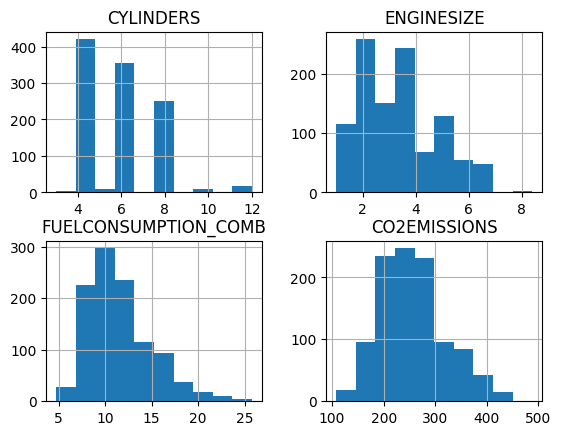

In [3]:
viz = df[['CYLINDERS','ENGINESIZE','FUELCONSUMPTION_COMB','CO2EMISSIONS']]
viz.hist()
plt.show()

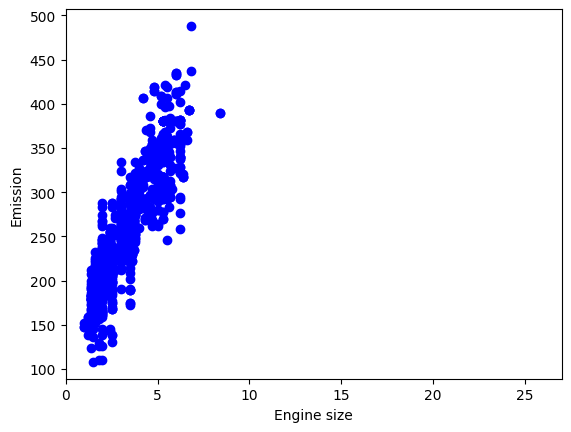

In [5]:
plt.scatter(viz.ENGINESIZE, viz.CO2EMISSIONS, color='blue')
plt.xlabel("Engine size")
plt.ylabel("Emission")
plt.xlim(0,27)
plt.show()

### `1.3` create dataset

In [7]:
X = viz.ENGINESIZE.to_numpy()
y = viz.CO2EMISSIONS.to_numpy()
display(X)
display(y)

array([2. , 2.4, 1.5, ..., 3. , 3.2, 3.2], shape=(1067,))

array([196, 221, 136, ..., 271, 260, 294], shape=(1067,))

In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(type(X_train), np.shape(X_train))
print(type(X_test), np.shape(X_test))

<class 'numpy.ndarray'> (853,)
<class 'numpy.ndarray'> (214,)


### `1.4` build linear regression model

In [9]:
from sklearn import linear_model

# 모델 객체 생성
regressor = linear_model.LinearRegression()

# 훈련 데이터로 모델 훈련
# X-train은 1-D array인데 sklearn model은 2D array (사건수,속성수)를 입력값으로 요구하므로 
# '-1'로 사건수 표현하고 입력값 재구성
regressor.fit(X_train.reshape(-1, 1), y_train)

# 계수 출력
print('Coefficients: ', regressor.coef_[0])
print('Intercept: ', regressor.intercept_)

Coefficients:  38.992978724434046
Intercept:  126.2897021740873


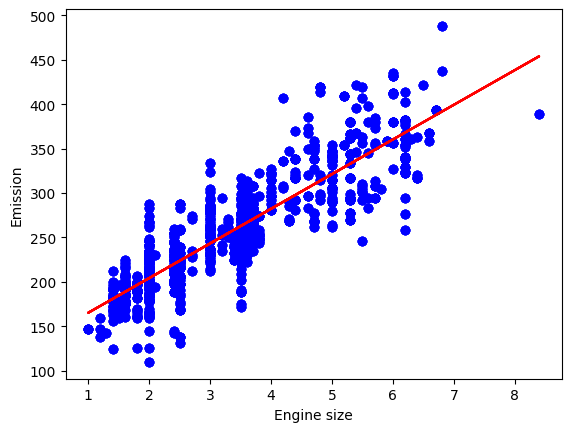

In [14]:
plt.scatter(X_train, y_train,  color='blue')
plt.plot(X_train, regressor.coef_ * X_train + regressor.intercept_, '-r')
plt.xlabel("Engine size")
plt.ylabel("Emission")
plt.show()

### `1.5` Model evaluation

- Mean Absolute Error
- **Mean Squared Error (MSE)**
- Root Mean Squared Error (RMSE)
- **R-squared** <br>= 1 - 잔차 제곱합 / 총 제곱합 <br>= 1 - (**실제값과 예측값**의 차이 제곱합(오차)) / (**실제값과 평균값**의 차이 제곱합(총 변동성))

In [15]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# X_test에 대한 예측 위해 predict method
# 2D array 입력값 shape reminde: (사건수, 속성수)
y_test_ = regressor.predict(X_test.reshape(-1, 1))

# 평가
# 실제값 y_test, 예측값 y_test_
print("Mean absolute error: %.2f" % mean_absolute_error(y_test, y_test_))
print("Mean squared error: %.2f" % mean_squared_error(y_test, y_test_))
print("Root mean squared error: %.2f" % np.sqrt(mean_squared_error(y_test, y_test_)))
print("R2-score: %.2f" % r2_score(y_test, y_test_))


Mean absolute error: 24.10
Mean squared error: 985.94
Root mean squared error: 31.40
R2-score: 0.76


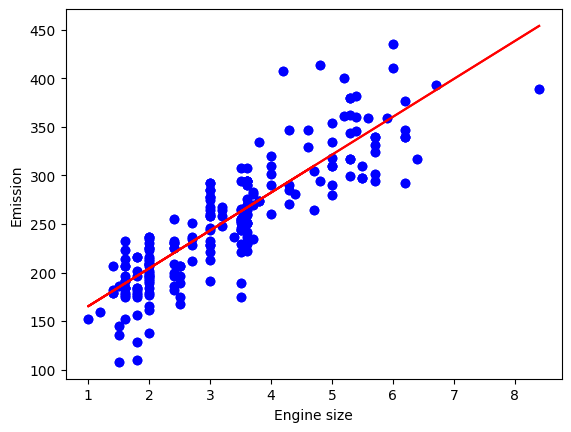

In [17]:
plt.scatter(X_test, y_test,  color='blue')
plt.plot(X_test, regressor.coef_ * X_test + regressor.intercept_, '-r')
plt.xlabel("Engine size")
plt.ylabel("Emission")
plt.show()

---

## `2` Multi Linear Regression

**계수를 추정하는 방식**
- `method 1.` **OLS** 
    - Ordinary Least Squares
    - MSE를 최소화하는 계수 값 추정
- `method 2.` **Optimization Approach**
    - 모델의 오차를 반복적으로 최소화하여 계수를 최적화하는 최적화 프로세스를 사용 
    - e.g. Gradient Descent

#### `2.1` select features

In [19]:
# 카테고리 데이터와 필요없는 열 삭제
df = df.drop(['MODELYEAR', 'MAKE', 'MODEL', 'VEHICLECLASS', 'TRANSMISSION', 'FUELTYPE',], axis=1)

In [21]:
df.corr()

,ENGINESIZE,CYLINDERS,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
ENGINESIZE,1.000000,0.934011,0.832225,0.778746,0.819482,-0.808554,0.874154
CYLINDERS,0.934011,1.000000,0.796473,0.724594,0.776788,-0.770430,0.849685
FUELCONSUMPTION_CITY,0.832225,0.796473,1.000000,0.965718,0.995542,-0.935613,0.898039
FUELCONSUMPTION_HWY,0.778746,0.724594,0.965718,1.000000,0.985804,-0.893809,0.861748
FUELCONSUMPTION_COMB,0.819482,0.776788,0.995542,0.985804,1.000000,-0.927965,0.892129
FUELCONSUMPTION_COMB_MPG,-0.808554,-0.770430,-0.935613,-0.893809,-0.927965,1.000000,-0.906394
CO2EMISSIONS,0.874154,0.849685,0.898039,0.861748,0.892129,-0.906394,1.000000


In [22]:
# correlation을 참고
# target value(CO2EMISSIONS)과 더 연관되어 있는지와 
# 다른 변수들간의 연관성을 토대로 열들 drop

df = df.drop(['CYLINDERS', 'FUELCONSUMPTION_CITY', 'FUELCONSUMPTION_HWY','FUELCONSUMPTION_COMB'], axis = 1)

display(df.head())

,ENGINESIZE,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
0,2.0,33,196
1,2.4,29,221
2,1.5,48,136
3,3.5,25,255
4,3.5,27,244


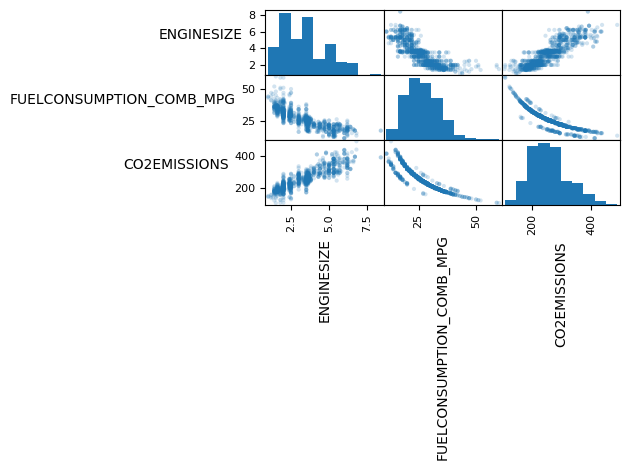

In [23]:
# 필요하지 않는 변수 선별을 위해 scatter plot 확인
# alpha는 그래픽 투명도
axes = pd.plotting.scatter_matrix(df, alpha=0.2)

# 라벨 읽기 위해 라벨 축 회전
for ax in axes.flatten():
    ax.xaxis.label.set_rotation(90)
    ax.yaxis.label.set_rotation(0)
    ax.yaxis.label.set_ha('right')  # set horizontal alignment : 오른쪽 정렬

plt.tight_layout()
# get current figure
# 서브플롯 간 간격 조정, width space, height space
plt.gcf().subplots_adjust(wspace=0, hspace=0)
plt.show()

#### `2.2` Preprocessing

In [25]:
# NumPy 어레이로 변환 (행은 사건, 열은 속성)
X = df.iloc[:,[0,1]].to_numpy()  # 두 개의 열 ENGINESIZE와 FUELCONSUMPTION_COMB_MPG
y = df.iloc[:, [2]].to_numpy()  # 마지막 target 열

In [26]:
from sklearn import preprocessing

# X 변수들 표준 정규화
# X_std = (x - μ) / 𝜎
std_scaler = preprocessing.StandardScaler()
X_std = std_scaler.fit_transform(X)

# 표준 정규화 결과 확인 : mean이 0, std가 1인지
pd.DataFrame(X_std).describe().round(2)

,0,1
count,1067.00,1067.00
mean,0.00,-0.00
std,1.00,1.00
min,-1.66,-2.07
25%,-0.95,-0.73
50%,0.04,-0.06
75%,0.67,0.61
max,3.57,4.50


In [27]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_std,y,test_size=0.2,random_state=42)

#### `2.3` build multiple linear regression model

In [28]:
from sklearn import linear_model

# model 객체 생성
regressor = linear_model.LinearRegression()

# train data 훈련 진행
regressor.fit(X_train, y_train)

# 계수 확인
coef_ = regressor.coef_
intercept_ = regressor.intercept_
print ('Coefficients: ',coef_)
print ('Intercept: ',intercept_)

Coefficients:  [[ 25.27339614 -37.4381472 ]]
Intercept:  [256.29072488]


In [29]:
# standard scaler의 mean과 std 파라미터들 가져오기
means_ = std_scaler.mean_
std_devs_ = np.sqrt(std_scaler.var_)

# 계수 복원
coef_original = coef_ / std_devs_

# 절편 복원
intercept_original = intercept_ - np.sum((means_ * coef_) / std_devs_)

print ('Coefficients: ', coef_original)
print ('Intercept: ', intercept_original)

Coefficients:  [[17.8581369  -5.01502179]]
Intercept:  [329.1363967]


#### `2.4` Visualize model outputs

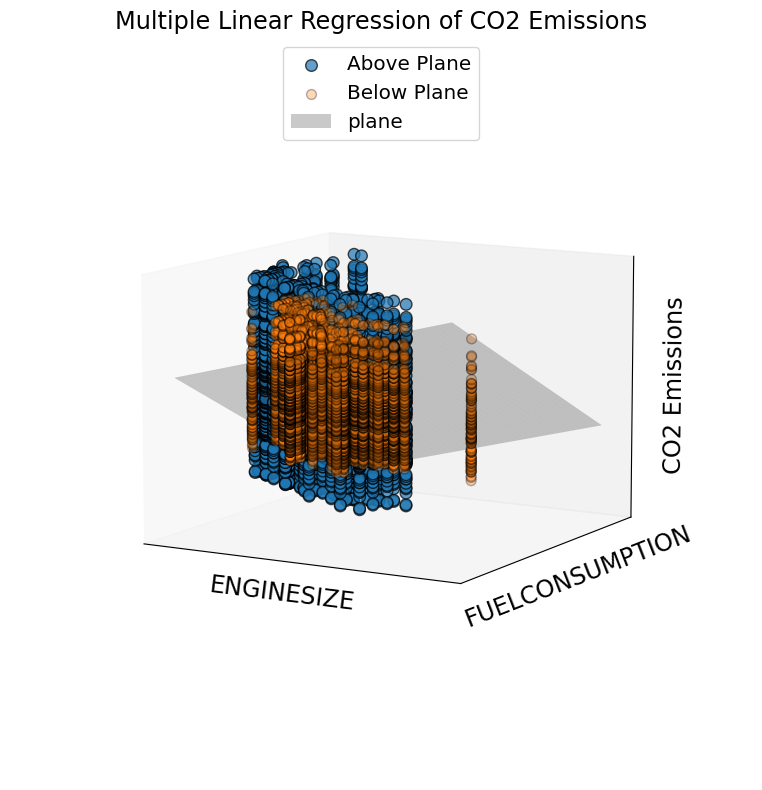

In [32]:
import numpy as np
import matplotlib.pyplot as plt

# 3D 플롯에 적합하도록 설정
X1 = X_test[:, 0] if X_test.ndim > 1 else X_test
X2 = X_test[:, 1] if X_test.ndim > 1 else np.zeros_like(X1)

# 회귀 평면을 위한 mesh grid 생성
x1_surf, x2_surf = np.meshgrid(np.linspace(X1.min(), X1.max(), 100),
                                np.linspace(X2.min(), X2.max(), 100))
y_surf = intercept_ + coef_[0,0] * x1_surf + coef_[0,1] * x2_surf

# X_test로 예측
y_pred = regressor.predict(X_test.reshape(-1,1)) if X_test.ndim == 1 else regressor.predict(X_test)
above_plane = y_test >= y_pred
below_plane = y_test < y_pred
above_plane = above_plane[:, 0]
below_plane = below_plane[:, 0]

# 플롯 준비
fig = plt.figure(figsize=(20,8))
ax = fig.add_subplot(111, projection='3d')

# 데이터 포인트 플롯
ax.scatter(X1[above_plane], X2[above_plane], y_test[above_plane], label="Above Plane", s=70, alpha=.7, ec='k')
ax.scatter(X1[below_plane], X2[below_plane], y_test[below_plane], label="Below Plane", s=50,alpha=.3,ec='k')

# 회귀 평면 플롯
ax.plot_surface(x1_surf, x2_surf, y_surf, color='k', alpha=0.21, label='plane')

# view와 label 설정
ax.view_init(elev=10)
ax.legend(fontsize='x-large',loc='upper center')
ax.set_xticks([])
ax.set_yticks([])
ax.set_zticks([])
ax.set_box_aspect(None, zoom=0.75)
ax.set_xlabel('ENGINESIZE', fontsize='xx-large')
ax.set_ylabel('FUELCONSUMPTION', fontsize='xx-large')
ax.set_zlabel('CO2 Emissions', fontsize='xx-large')
ax.set_title('Multiple Linear Regression of CO2 Emissions', fontsize='xx-large')
plt.tight_layout()
plt.show()

- **Non Linear Regression** could be **polynomial, exponential, logarithmic, sinusodial**

---

## `3` Logistic Regression

- 로지스틱 회귀 훈련 단계
    1. θ로 정의된 초기 파라미터 값을 정의함
    2. 데이터의 각 관측치에 대해 클래스=1일 확률 예측
    3. 예측 클래스와 실제 클래스 간의 오차(=cost function or log-loss) 측정
    4. cost function를 줄이는 θ로 업데이트 (gradient descent)
    5. 반복 : 충분히 작은 log-loss이나 최대 반복횟수 도달할 때까지

- **`Log-loss`** 
    - 클래스가 1인 예측 확률 p-hat-i가 실제 클래스 yi와 얼마나 일치하는지를 측정하는 함수
    - 로그함수는 x=1보다 작을 때 음수이므로 (-)를 곱함
    - e.g. [y=1인데 p=0.9인 경우] -log(p)가 손실이며 대입하면 손실이 작음

$$
L(y, p) = -\frac{1}{N} \sum_{i=1}^{N} \Big[ y_i \log p_i + (1 - y_i) \log (1 - p_i) \Big]
$$

- **`Gradient descent`**
    - cost function을 최소화하는 최적의 파라미터 값을 구할 때 사용하는 방법론
    - 함수의 최솟값을 찾기 위한 반복적 접근법
    - learning rate를 통해 파라미터들을 얼마나 움직일지 통제함
    - 전체 데이터셋을 활용하여 계산하는데, 계산 비용을 줄이기 위해 랜덤 하위 집합을 선택 가능
    - **Stochastic gradient descent(SGD)**
        - 확률적 경사하강법, 랜덤 하위 집합 활용
        - 속도는 빠르지만 정확도가 떨어질 수 있음
        - local minima는 간과하고 global minima를 찾을 가능성이 더 큼

#### `3.1` Import libraries and Loading data

In [34]:
!pip install numpy==2.2.0
!pip install pandas==2.2.3
!pip install scikit-learn==1.6.0
!pip install matplotlib==3.9.3

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import log_loss
import matplotlib.pyplot as plt

%matplotlib inline 

import warnings
warnings.filterwarnings('ignore')

In [35]:
# Telco Churn data set
# telecommunications company's efforts to reduce turnover in its customer base. 
# Each case corresponds to a separate customer and it records various demographic and service usage information.

url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML0101EN-SkillsNetwork/labs/Module%203/data/ChurnData.csv"
churn_df = pd.read_csv(url)

churn_df

,tenure,age,address,income,ed,employ,equip,callcard,wireless,longmon,...,pager,internet,callwait,confer,ebill,loglong,logtoll,lninc,custcat,churn
0,11.0,33.0,7.0,136.0,5.0,5.0,0.0,1.0,1.0,4.40,...,1.0,0.0,1.0,1.0,0.0,1.482,3.033,4.913,4.0,1.0
1,33.0,33.0,12.0,33.0,2.0,0.0,0.0,0.0,0.0,9.45,...,0.0,0.0,0.0,0.0,0.0,2.246,3.240,3.497,1.0,1.0
2,23.0,30.0,9.0,30.0,1.0,2.0,0.0,0.0,0.0,6.30,...,0.0,0.0,0.0,1.0,0.0,1.841,3.240,3.401,3.0,0.0
3,38.0,35.0,5.0,76.0,2.0,10.0,1.0,1.0,1.0,6.05,...,1.0,1.0,1.0,1.0,1.0,1.800,3.807,4.331,4.0,0.0
4,7.0,35.0,14.0,80.0,2.0,15.0,0.0,1.0,0.0,7.10,...,0.0,0.0,1.0,1.0,0.0,1.960,3.091,4.382,3.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,55.0,44.0,24.0,83.0,1.0,23.0,0.0,1.0,0.0,17.35,...,0.0,0.0,0.0,1.0,0.0,2.854,3.199,4.419,3.0,0.0
196,34.0,23.0,3.0,24.0,1.0,7.0,0.0,1.0,0.0,6.00,...,0.0,0.0,1.0,1.0,0.0,1.792,3.332,3.178,3.0,0.0
197,6.0,32.0,10.0,47.0,1.0,10.0,0.0,1.0,0.0,3.85,...,0.0,0.0,1.0,1.0,0.0,1.348,3.168,3.850,3.0,0.0
198,24.0,30.0,0.0,25.0,4.0,5.0,0.0,1.0,1.0,8.70,...,1.0,1.0,1.0,1.0,1.0,2.163,3.866,3.219,4.0,1.0


#### `3.2` Preprocessing

In [36]:
# 정수 타입으로 변화
churn_df = churn_df[['tenure', 'age', 'address', 'income', 'ed', 'employ', 'equip', 'churn']]
churn_df['churn'] = churn_df['churn'].astype('int')

# NumPy 어레이로 X, y 생성
X = np.asarray(churn_df[['tenure', 'age', 'address', 'income', 'ed', 'employ', 'equip']])

y = np.asarray(churn_df['churn'])

# X 정규화 (평균 0, 분산 1)
X_norm = StandardScaler().fit(X).transform(X)

# 데이터셋 분리
X_train, X_test, y_train, y_test = train_test_split( X_norm, y, test_size=0.2, random_state=4)

#### `3.3` Logistic Regression Classifier modeling

In [37]:
# 모델
LR = LogisticRegression().fit(X_train, y_train)

# 예측 y값
yhat = LR.predict(X_test)

# 예측 확률 p값
yhat_prob = LR.predict_proba(X_test)

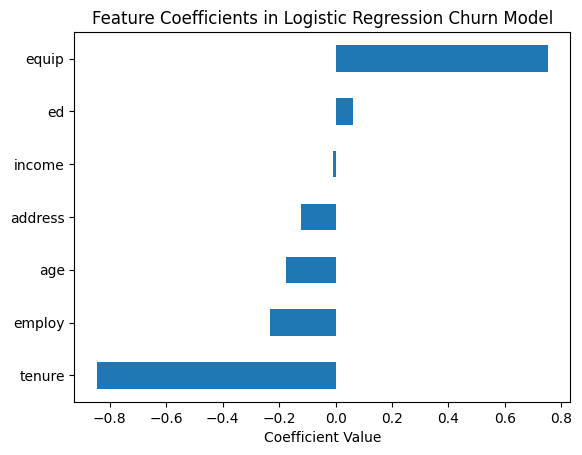

In [38]:
# 입력 속성별 영향 확인
coefficients = pd.Series(LR.coef_[0], index=churn_df.columns[:-1])
coefficients.sort_values().plot(kind='barh')
plt.title("Feature Coefficients in Logistic Regression Churn Model")
plt.xlabel("Coefficient Value")
plt.show()

In [39]:
log_loss(y_test, yhat_prob)  # 작을 수록 좋은 모델

0.6257718410257235

---

## `4` Multi-class classification

#### `4.1` Import libraries

In [40]:
!pip install numpy==2.2.0
!pip install pandas==2.2.3
!pip install scikit-learn==1.6.0
!pip install matplotlib==3.9.3
!pip install seaborn==0.13.2

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsOneClassifier
from sklearn.metrics import accuracy_score

import warnings
warnings.filterwarnings('ignore')

#### `4.2` Exploratory Data Analysis

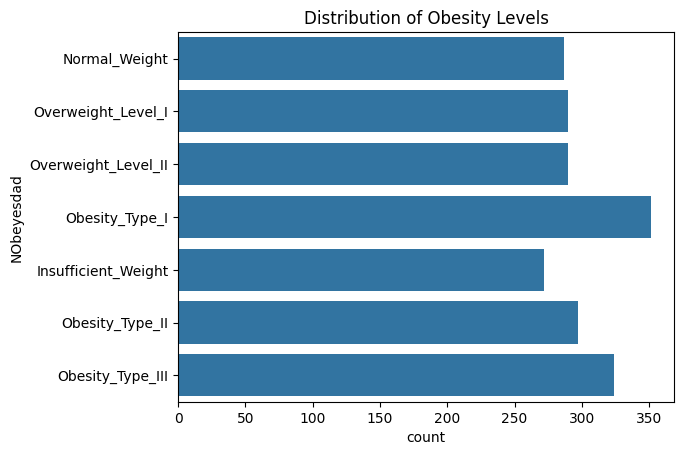

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          2111 non-null   object 
 1   Age                             2111 non-null   float64
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   family_history_with_overweight  2111 non-null   object 
 5   FAVC                            2111 non-null   object 
 6   FCVC                            2111 non-null   float64
 7   NCP                             2111 non-null   float64
 8   CAEC                            2111 non-null   object 
 9   SMOKE                           2111 non-null   object 
 10  CH2O                            2111 non-null   float64
 11  SCC                             2111 non-null   object 
 12  FAF                             21

None

,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE
count,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000
mean,24.312600,1.701677,86.586058,2.419043,2.685628,2.008011,1.010298,0.657866
std,6.345968,0.093305,26.191172,0.533927,0.778039,0.612953,0.850592,0.608927
min,14.000000,1.450000,39.000000,1.000000,1.000000,1.000000,0.000000,0.000000
25%,19.947192,1.630000,65.473343,2.000000,2.658738,1.584812,0.124505,0.000000
50%,22.777890,1.700499,83.000000,2.385502,3.000000,2.000000,1.000000,0.625350
75%,26.000000,1.768464,107.430682,3.000000,3.000000,2.477420,1.666678,1.000000
max,61.000000,1.980000,173.000000,3.000000,4.000000,3.000000,3.000000,2.000000


In [41]:
file_path = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/GkDzb7bWrtvGXdPOfk6CIg/Obesity-level-prediction-dataset.csv"
data = pd.read_csv(file_path)


# target 변수의 분포 확인
sns.countplot(y='NObeyesdad', data=data)
plt.title('Distribution of Obesity Levels')
plt.show()

display(data.info())
display(data.describe())

#### `4.3` Preprocessing

In [42]:
# Feature scaling

# 연속형 변수들 리스트
continuous_columns = data.select_dtypes(include=['float64']).columns.tolist()

# 연속형 변수들 정규화
scaler = StandardScaler()
scaled_features = scaler.fit_transform(data[continuous_columns])

# df로 변환
scaled_df = pd.DataFrame(scaled_features, columns=scaler.get_feature_names_out(continuous_columns))

# 기존 데이터셋과 결합
scaled_data = pd.concat([data.drop(columns=continuous_columns), scaled_df], axis=1)

In [43]:
# One-hot encoding

# 카데고리형 변수들 리스트
categorical_columns = scaled_data.select_dtypes(include=['object']).columns.tolist()
categorical_columns.remove('NObeyesdad')  # target 변수 제외

# 원핫인코딩
encoder = OneHotEncoder(sparse_output=False, drop='first')
encoded_features = encoder.fit_transform(scaled_data[categorical_columns])

# df로 변환
encoded_df = pd.DataFrame(encoded_features, columns=encoder.get_feature_names_out(categorical_columns))

# 기존 데이터셋과 결합
prepped_data = pd.concat([scaled_data.drop(columns=categorical_columns), encoded_df], axis=1)


In [44]:
# target 변수 인코딩
prepped_data['NObeyesdad'] = prepped_data['NObeyesdad'].astype('category').cat.codes
prepped_data.head()

,NObeyesdad,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE,Gender_Male,...,CAEC_no,SMOKE_yes,SCC_yes,CALC_Frequently,CALC_Sometimes,CALC_no,MTRANS_Bike,MTRANS_Motorbike,MTRANS_Public_Transportation,MTRANS_Walking
0,1,-0.522124,-0.875589,-0.862558,-0.785019,0.404153,-0.013073,-1.188039,0.561997,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
1,1,-0.522124,-1.947599,-1.168077,1.088342,0.404153,1.618759,2.339750,-1.080625,0.0,...,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
2,1,-0.206889,1.054029,-0.366090,-0.785019,0.404153,-0.013073,1.163820,0.561997,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
3,5,0.423582,1.054029,0.015808,1.088342,0.404153,-0.013073,1.163820,-1.080625,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
4,6,-0.364507,0.839627,0.122740,-0.785019,-2.167023,-0.013073,-1.188039,-1.080625,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0


In [45]:
X = prepped_data.drop('NObeyesdad', axis=1)
y = prepped_data['NObeyesdad']

# 데이터셋 분리
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

#### `4.4` Logistic Regression with One-vs-All

In [46]:
# 로지스틱 회귀 default 설정인 One-vs-All 방식으로 학습
model_ova = LogisticRegression(multi_class='ovr', max_iter=1000)
model_ova.fit(X_train, y_train)

# 예측 수행
y_pred_ova = model_ova.predict(X_test)

# OvA의 정확도 확인
print("One-vs-All (OvA) Strategy")
print(f"Accuracy: {np.round(100*accuracy_score(y_test, y_pred_ova),2)}%")

One-vs-All (OvA) Strategy
Accuracy: 76.12%


#### `4.5` Logistic Regression with One-vs-One

In [47]:
# 로지스틱 회귀 One-vs-One 방식으로 학습
model_ovo = OneVsOneClassifier(LogisticRegression(max_iter=1000))
model_ovo.fit(X_train, y_train)

# 예측 수행
y_pred_ovo = model_ovo.predict(X_test)

# OvO의 정확도 확인
print("One-vs-One (OvO) Strategy")
print(f"Accuracy: {np.round(100*accuracy_score(y_test, y_pred_ovo),2)}%")

One-vs-One (OvO) Strategy
Accuracy: 92.2%


---

## `5` Decision Trees

- 의사결정나무 학습 과정
    1. 시드 노드와 라벨링된 train data로 시작
    2. data를 가장 잘 분리하는 feature를 찾음
    3. 각 분할은 노드의 입력 데이터를 나눔
    4. 각 새로운 노드에 대해 이 과정을 반복함

- **Tree pruning**
    - 트리 성장을 다음과 같은 상황에서 중단
        - Maximum tree depth
        - Minimum number of data points in a node
        - Minimum number of samples in a leaf
        - Maximum number of leaf nodes

- 분할 기준 : **엔트로피**가 작아지는 방향으로
    - **Information gain** : (분할 전 트리의 엔트로피) - (분할 후 가중 엔트로피)
    - Gini impurity

#### `5.1` Importing libraries and loading data

In [48]:
!pip install numpy==2.2.0
!pip install pandas==2.2.3
!pip install scikit-learn==1.6.0
!pip install matplotlib==3.9.3

import numpy as np 
import pandas as pd
from matplotlib import pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn import metrics

%matplotlib inline

import warnings
warnings.filterwarnings('ignore')

path= 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML0101EN-SkillsNetwork/labs/Module%203/data/drug200.csv'
my_data = pd.read_csv(path)

#### `5.2` EDA and preprocessing

In [49]:
display(my_data.info())

# 카테고리 데이터들을 숫자형으로 변환 - LabelEncoder 활용
label_encoder = LabelEncoder()  # 객체 생성
my_data['Sex'] = label_encoder.fit_transform(my_data['Sex'])
my_data['BP'] = label_encoder.fit_transform(my_data['BP'])
my_data['Cholesterol'] = label_encoder.fit_transform(my_data['Cholesterol'])
display(my_data)

display(my_data.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          200 non-null    int64  
 1   Sex          200 non-null    object 
 2   BP           200 non-null    object 
 3   Cholesterol  200 non-null    object 
 4   Na_to_K      200 non-null    float64
 5   Drug         200 non-null    object 
dtypes: float64(1), int64(1), object(4)
memory usage: 9.5+ KB


None

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,0,0,0,25.355,drugY
1,47,1,1,0,13.093,drugC
2,47,1,1,0,10.114,drugC
3,28,0,2,0,7.798,drugX
4,61,0,1,0,18.043,drugY
...,...,...,...,...,...,...
195,56,0,1,0,11.567,drugC
196,16,1,1,0,12.006,drugC
197,52,1,2,0,9.894,drugX
198,23,1,2,1,14.020,drugX


Age            0
Sex            0
BP             0
Cholesterol    0
Na_to_K        0
Drug           0
dtype: int64

In [50]:
# target 변수의 카테고리들을 정수형으로 표현한 열 생성
custom_map = {'drugA':0, 'drugB':1, 'drugC':2, 'drugX':3, 'drugY':4}
my_data['Drug_num'] = my_data['Drug'].map(custom_map)

# 모두 숫자형으로 변환되었으므로 상관관계 확인 가눙
my_data.drop('Drug',axis=1).corr()['Drug_num']

Age           -0.004828
Sex           -0.098573
BP             0.372868
Cholesterol    0.055629
Na_to_K        0.589120
Drug_num       1.000000
Name: Drug_num, dtype: float64

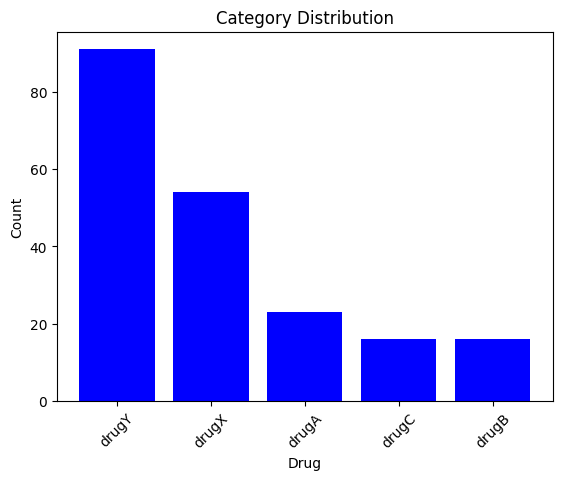

In [51]:
# target 변수의 빈도 확인
category_counts = my_data['Drug'].value_counts()

# Plot the count plot
plt.bar(category_counts.index, category_counts.values, color='blue')
plt.xlabel('Drug')
plt.ylabel('Count')
plt.title('Category Distribution')
plt.xticks(rotation=45)  # Rotate labels for better readability if needed
plt.show()

#### `5.3` Modeling

In [52]:
y = my_data['Drug']
X = my_data.drop(['Drug','Drug_num'], axis=1)

X_trainset, X_testset, y_trainset, y_testset = train_test_split(X, y, test_size=0.3, random_state=32)

drugTree = DecisionTreeClassifier(criterion="entropy", max_depth=4)
drugTree.fit(X_trainset,y_trainset)

DecisionTreeClassifier(criterion='entropy', max_depth=4)

#### `5.4` Evaluation

Decision Trees's Accuracy:  0.9833333333333333


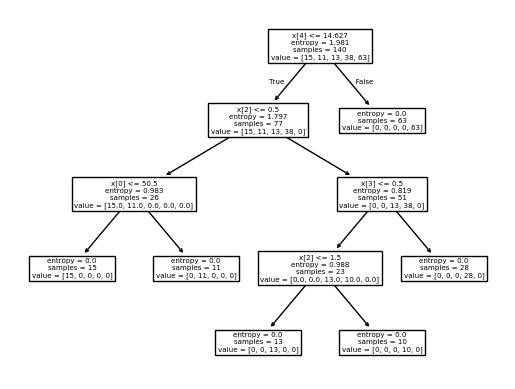

In [53]:
tree_predictions = drugTree.predict(X_testset)

print("Decision Trees's Accuracy: ", metrics.accuracy_score(y_testset, tree_predictions))

plot_tree(drugTree)
plt.show()

결과 해석

Drug A : $Na\_to\_K <= 14.627,\ BP = High,\ Age <= 50.5$<br>
Drug B : $Na\_to\_K <= 14.627,\ BP = High,\ Age > 50.5$<br>
Drug C : $Na\_to\_K <= 14.627,\ BP = Low,\ Cholesterol <= High$<br>
Drug X : $Na\_to\_K <= 14.627,\ BP = Normal,\ Cholesterol = High$<br>
Drug Y : $Na\_to\_K > 14.627$



---

## `6` Regression Trees

| 구분                        | 분류 트리 (Classification Trees)          | 회귀 트리 (Regression Trees)                |
|-----------------------------|-------------------------------------------|---------------------------------------------|
| 목적 (Objective)            | 데이터를 이산 집합으로 분류                | 연속형 목표 변수를 예측                     |
| 목표 변수 (Target Variable) | 범주형 (Categorical)                      | 실수형 (Float)                              |
| 분할 기준 (Splitting Criterion) | 지니 불순도(Gini impurity) 또는 엔트로피(Entropy) | 분산 감소 (Variance reduction)<br> MSE 감소             |
| 리프 노드 예측 (Prediction at Leaf Nodes) | 클래스 레이블 다수결 투표                 | 목표 값의 평균 (Average value of target values) |


#### `6.1` Importing libraries and loading data

In [55]:
!pip install numpy
!pip install pandas
!pip install matplotlib
!pip install scikit-learn

from __future__ import print_function
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import normalize
from sklearn.metrics import mean_squared_error

import warnings
warnings.filterwarnings('ignore')

url = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/pu9kbeSaAtRZ7RxdJKX9_A/yellow-tripdata.csv'
raw_data = pd.read_csv(url)

#### `6.2` EDA and Preprocessing

In [56]:
# target 변수 Input 변수들간의 상관관계 시각화
correlation_values = raw_data.corr()['tip_amount'].drop('tip_amount')
correlation_values.plot(kind='barh', figsize=(10, 6))

<Axes: >

In [57]:
# 라벨을 실수로 바꿈
y = raw_data[['tip_amount']].values.astype('float32')


proc_data = raw_data.drop(['tip_amount'], axis=1)

# feature matrix 생성
X = proc_data.values

# feature matrix 정규화
X = normalize(X, axis=1, norm='l1', copy=False)

In [58]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

#### `6.3` Modeling

In [59]:
from sklearn.tree import DecisionTreeRegressor

df_reg = DecisionTreeRegressor(criterion='squared_error', max_depth=8, random_state=35)

df_reg.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=8, random_state=35)

#### `6.3` Evaluate

In [62]:
y_pred = df_reg.predict(X_test)

# 테스트셋에서의 MSE값을 계산
mse_score = mean_squared_error(y_test, y_pred)
print('MSE score : {0:.3f}'.format(mse_score))

# 테스트셋에서의 R^2값을 계산
r2_score = df_reg.score(X_test,y_test)
print('R^2 score : {0:.3f}'.format(r2_score))

MSE score : 24.555
R^2 score : 0.028


In [63]:
# top 3 features with the most effect on the tip_amount
correlation_values = raw_data.corr()['tip_amount'].drop('tip_amount')
abs(correlation_values).sort_values(ascending=False)[:3]

fare_amount      0.200638
tolls_amount     0.116172
trip_distance    0.101819
Name: tip_amount, dtype: float64

In [64]:
# 4개의 상관성이 낮은 변수들을 제외하고 다시 학습 진행하여 평가하기

# 변수 드랍***
raw_data = raw_data.drop(['payment_type', 'VendorID', 'store_and_fwd_flag', 'improvement_surcharge'], axis=1)

# 라벨을 실수로 바꿈
y = raw_data[['tip_amount']].values.astype('float32')

proc_data = raw_data.drop(['tip_amount'], axis=1)

# feature matrix 생성
X = proc_data.values

# feature matrix 정규화
X = normalize(X, axis=1, norm='l1', copy=False)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

from sklearn.tree import DecisionTreeRegressor

df_reg = DecisionTreeRegressor(criterion='squared_error', max_depth=8, random_state=35)

df_reg.fit(X_train, y_train)

y_pred = df_reg.predict(X_test)

# 테스트셋에서의 MSE값을 계산
mse_score = mean_squared_error(y_test, y_pred)
print('MSE score : {0:.3f}'.format(mse_score))

# 테스트셋에서의 R^2값을 계산
r2_score = df_reg.score(X_test,y_test)
print('R^2 score : {0:.3f}'.format(r2_score))

MSE score : 24.709
R^2 score : 0.022


In [65]:
# max_depth 변수를 줄이고 다시 평가
df_reg = DecisionTreeRegressor(criterion='squared_error', max_depth=4, random_state=35)

df_reg.fit(X_train, y_train)

y_pred = df_reg.predict(X_test)

# 테스트셋에서의 MSE값을 계산
mse_score = mean_squared_error(y_test, y_pred)
print('MSE score : {0:.3f}'.format(mse_score))

# 테스트셋에서의 R^2값을 계산
r2_score = df_reg.score(X_test,y_test)
print('R^2 score : {0:.3f}'.format(r2_score))

MSE score : 24.468
R^2 score : 0.031


max_depth=4가 더 적합한 파라미터라는 결론.

---

## `7` SVM

- 목표
    - 데이터셋을 분리하는 초평면을 생성하고자 함
    - maximizing margin <-> minimizing mis-classification : 파라미터에 의해 제어됨

- **margin** : 초평면에서 각 클래스의 가장 가까운 포인트까지의 거리
- **support vectors** : 각 클래스의 가장 가까운 대표 포인트
- **decision boundary**(결정경계) : 마진을 최대화하는 초평면

- 선형적으로 분리할 수 없는 경우
    - e.g. Parabolic 3D embedding
    - **kerneling** : 고차원 공간에 데이터를 매핑하는 것
    - SVM을 위한 scikit-learn Kernel functions
        - linear
        - polynomial
        - Radio based functions (방사형)
        - Sigmoid

#### `7.1` Importing libraries and loading data

In [66]:
!pip install pandas==2.2.3
!pip install scikit-learn==1.6.0
!pip install matplotlib==3.9.3

# Import the libraries we need to use in this lab
from __future__ import print_function
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import normalize, StandardScaler
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import roc_auc_score
from sklearn.svm import LinearSVC

import warnings
warnings.filterwarnings('ignore')

# download the dataset
url= "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML0101EN-SkillsNetwork/labs/Module%203/data/creditcard.csv"

# read the input data
raw_data=pd.read_csv(url)

#### `7.2` EDA and preprocessing

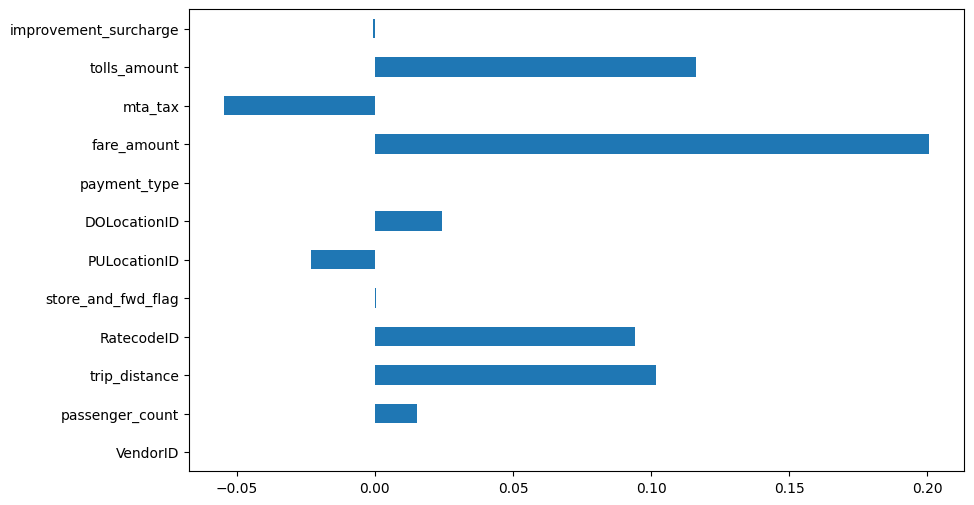

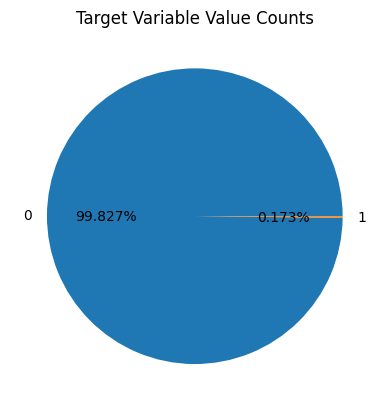

In [67]:
# 클래스 라벨 추출
labels = raw_data.Class.unique()

# 각 클래스 빈도
sizes = raw_data.Class.value_counts().values

# plot
fig, ax = plt.subplots()
ax.pie(sizes, labels=labels, autopct='%1.3f%%')
ax.set_title('Target Variable Value Counts')
plt.show()

In [68]:
# 각 features의 상관성 확인
correlation_values = raw_data.corr()['Class'].drop('Class')
correlation_values.plot(kind='barh', figsize=(10, 6))

<Axes: >

In [69]:
# 열별 표준화 : 각 특성의 분포를 표준화
raw_data.iloc[:, 1:30] = StandardScaler().fit_transform(raw_data.iloc[:, 1:30])
data_matrix = raw_data.values

# X: feature matrix (for this analysis, we exclude the Time variable from the dataset)
X = data_matrix[:, 1:30]

# y: labels vector
y = data_matrix[:, 30]

# 행별 정규화 : 각 데이터 포인트의 크기를 일정하게 맞춤 (KNN에서 필요한 과정)
X = normalize(X, norm="l1")

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

#### `7.3` Modeling

In [70]:
# DecisionTreeClassifier
# class imbalance를 고려하여 표본 가중치 계산
w_train = compute_sample_weight('balanced', y_train)

dt = DecisionTreeClassifier(max_depth=4, random_state=35)

dt.fit(X_train, y_train, sample_weight=w_train)

DecisionTreeClassifier(max_depth=4, random_state=35)

In [71]:
# SVM
# 가중치 계산 필요없음
svm = LinearSVC(class_weight='balanced', random_state=31, loss="hinge", fit_intercept=False)

svm.fit(X_train, y_train)

LinearSVC(class_weight='balanced', fit_intercept=False, loss='hinge',
          random_state=31)

#### `7.4` Evaluate

In [72]:
# DecisionTreeClassifier
y_pred_dt = dt.predict_proba(X_test)[:,1]

roc_auc_dt = roc_auc_score(y_test, y_pred_dt)
print('Decision Tree ROC-AUC score : {0:.3f}'.format(roc_auc_dt))

Decision Tree ROC-AUC score : 0.939


In [73]:
# Support Vector Machine
y_pred_svm = svm.decision_function(X_test)

roc_auc_svm = roc_auc_score(y_test, y_pred_svm)
print("SVM ROC-AUC score: {0:.3f}".format(roc_auc_svm))

SVM ROC-AUC score: 0.986


---

## `8` K-Nearest_neighbor Classifier

#### `8.1` Importing libraries and loading data

In [74]:
!pip install numpy==2.2.0
!pip install pandas==2.2.3
!pip install scikit-learn==1.6.0
!pip install matplotlib==3.9.3
!pip install seaborn==0.13.2

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
%matplotlib inline

df = pd.read_csv('https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML0101EN-SkillsNetwork/labs/Module%203/data/teleCust1000t.csv')

df.head()

,region,tenure,age,marital,address,income,ed,employ,retire,gender,reside,custcat
0,2,13,44,1,9,64.0,4,5,0.0,0,2,1
1,3,11,33,1,7,136.0,5,5,0.0,0,6,4
2,3,68,52,1,24,116.0,1,29,0.0,1,2,3
3,2,33,33,0,12,33.0,2,0,0.0,1,1,1
4,2,23,30,1,9,30.0,1,2,0.0,0,4,3


#### `8.2` EDA and preprocessing

In [75]:
# 클래스 분포 확인
display(df['custcat'].value_counts())

# 상관관계 확인
correlation_matrix = df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)

correlation_values = abs(df.corr()['custcat'].drop('custcat')).sort_values(ascending=False)
display(correlation_values)

X = df.drop('custcat',axis=1)
y = df['custcat']

# 정규화
X_norm = StandardScaler().fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_norm, y, test_size=0.2, random_state=4)

custcat
3    281
1    266
4    236
2    217
Name: count, dtype: int64

ed         0.193864
tenure     0.166691
income     0.134525
employ     0.110011
marital    0.083836
reside     0.082022
address    0.067913
age        0.056909
region     0.023771
retire     0.008908
gender     0.004966
Name: custcat, dtype: float64

#### `8.3` KNN classification

In [76]:
# 학습
k = 3
knn_classifier = KNeighborsClassifier(n_neighbors=k)
knn_model = knn_classifier.fit(X_train, y_train)

yhat = knn_model.predict(X_test)

# 정확도 평가
print("Test set Accuracy: ", accuracy_score(y_test, yhat))

Test set Accuracy:  0.315


In [77]:
# k값 바꿔보기
k = 6
knn_model_6 = KNeighborsClassifier(n_neighbors = k).fit(X_train,y_train)
yhat6 = knn_model_6.predict(X_test)
print("Test set Accuracy: ", accuracy_score(y_test, yhat6))

Test set Accuracy:  0.31


#### `8.4` choosing the correct value of k

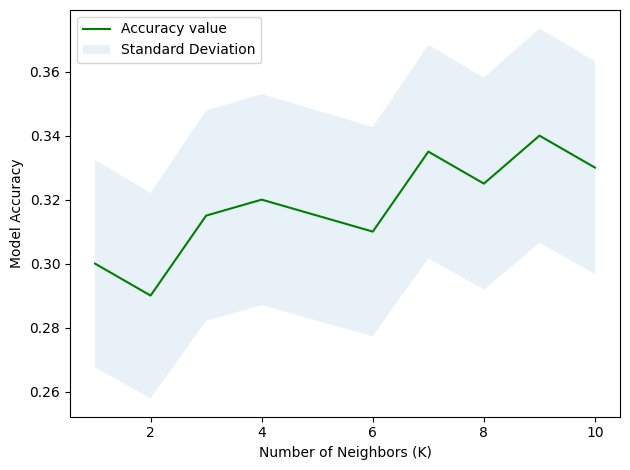

In [81]:
Ks = 10
acc = np.zeros((Ks))
std_acc = np.zeros((Ks))
for n in range(1,Ks+1):
    #Train Model and Predict  
    knn_model_n = KNeighborsClassifier(n_neighbors = n).fit(X_train,y_train)
    yhat = knn_model_n.predict(X_test)
    acc[n-1] = accuracy_score(y_test, yhat)
    std_acc[n-1] = np.std(yhat==y_test)/np.sqrt(yhat.shape[0])

# 시각화
plt.plot(range(1,Ks+1),acc,'g')
plt.fill_between(range(1,Ks+1),acc - 1 * std_acc,acc + 1 * std_acc, alpha=0.10)
plt.legend(('Accuracy value', 'Standard Deviation'))
plt.ylabel('Model Accuracy')
plt.xlabel('Number of Neighbors (K)')
plt.tight_layout()
plt.show()

In [79]:
print( "The best accuracy was with", acc.max(), "with k =", acc.argmax()+1) 

The best accuracy was with 0.34 with k = 9


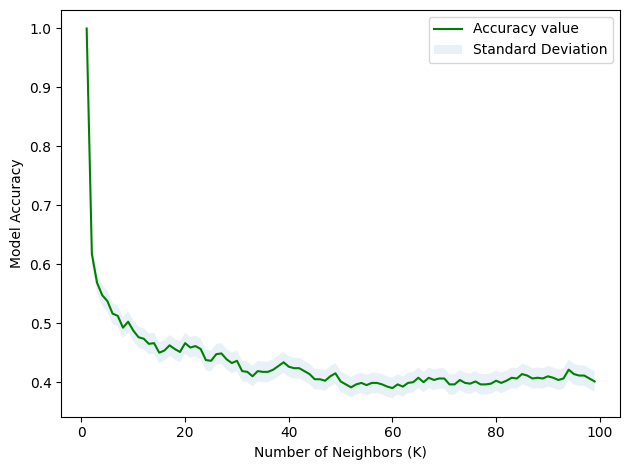

In [80]:
# 100 value of Ks

Ks =100
acc = np.zeros((Ks-1))
std_acc = np.zeros((Ks-1))
for n in range(1,Ks):
    #Train Model and Predict  
    knn_model_n = KNeighborsClassifier(n_neighbors = n).fit(X_train,y_train)
    yhat = knn_model_n.predict(X_train)
    acc[n-1] = accuracy_score(y_train, yhat)
    std_acc[n-1] = np.std(yhat==y_train)/np.sqrt(yhat.shape[0])

plt.plot(range(1,Ks),acc,'g')
plt.fill_between(range(1,Ks),acc - 1 * std_acc, acc + 1 * std_acc, alpha=0.10)
plt.legend(('Accuracy value', 'Standard Deviation'))
plt.ylabel('Model Accuracy')
plt.xlabel('Number of Neighbors (K)')
plt.tight_layout()
plt.show()

---

## `9` Random Forests and XGBoost

- **Bias(편향) and Variance(분산) tradeoff**
    - 모델이 과소적합되면 bias가 커지고, variance가 줄어듦
    - 모델이 과적합되면 variance가 커지고, bias가 줄어듦
    - how to find balance in bias and variance? Bagging and Boosting

- **Ensemble techniqus**
    1. **Bagging (Bootstrap Aggregating)** : 복원추출(bootstrap)된 데이터 하위집합을 활용하여 여러 번 학습 진행하여 예측 결과를 평균냄
        - e.g. Random Forest
        - 과적합을 완화함 (분산 감소)
    2. **Boosting** : weak learners들을 다수 만들고 각 learners가 previous learner의 오차를 학습함. 시스템적으로 예측 오차를 줄임. 최종 모델은 가중화된 weak learners들을 종합
        - e.g. Gradient Boosting, XGBoost, AdaBoost
        - 과소적합을 완화함 (편향 감소)

#### `9.1` Importing libraries, loading data

In [82]:
!pip install numpy==2.2.0
!pip install scikit-learn==1.6.0
!pip install matplotlib==3.9.3
!pip install xgboost==2.1.3

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score
import time

# 데이터 로드
data = fetch_california_housing()
X, y = data.data, data.target

# 학습, 테스트 데이터셋 구성
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

   ---------------------------------------- 0.0/124.9 MB ? eta -:--:--
   ---------------------------------------- 0.3/124.9 MB ? eta -:--:--
   ---------------------------------------- 0.3/124.9 MB ? eta -:--:--
   ---------------------------------------- 0.5/124.9 MB 718.4 kB/s eta 0:02:54
   ---------------------------------------- 0.5/124.9 MB 718.4 kB/s eta 0:02:54
   ---------------------------------------- 0.5/124.9 MB 718.4 kB/s eta 0:02:54
   ---------------------------------------- 0.8/124.9 MB 551.3 kB/s eta 0:03:46
   ---------------------------------------- 0.8/124.9 MB 551.3 kB/s eta 0:03:46
   ---------------------------------------- 0.8/124.9 MB 551.3 kB/s eta 0:03:46
   ---------------------------------------- 1.0/124.9 MB 471.4 kB/s eta 0:04:23
   ---------------------------------------- 1.0/124.9 MB 471.4 kB/s eta 0:04:23
   ---------------------------------------- 1.0/124.9 MB 471.4 kB/s eta 0:04:23
   ---------------------------------------- 1.0/124.9 MB 471.4 kB/s

In [83]:
# 데이터셋 크기 확인
N_observations, N_features = X.shape
print('Number of Observations: ' + str(N_observations))
print('Number of Features: ' + str(N_features))

Number of Observations: 20640
Number of Features: 8


#### `9.2` 모델 훈련

In [84]:
# 모델 초기화
n_estimators = 100
rf = RandomForestRegressor(n_estimators=n_estimators, random_state=42)
xgb = XGBRegressor(n_estimators=n_estimators, random_state=42)

In [85]:
# 모델 fit
# 훈련시간 측정

start_time_rf = time.time()
rf.fit(X_train, y_train)
end_time_rf = time.time()
rf_train_time = end_time_rf - start_time_rf

start_time_xgb = time.time()
xgb.fit(X_train, y_train)
end_time_xgb = time.time()
xgb_train_time = end_time_xgb - start_time_xgb

#### `9.3` 모델 평가

In [86]:
# 모델 예측
# 예측시간 측정

start_time_rf = time.time()
y_pred_rf = rf.predict(X_test)
end_time_rf = time.time()
rf_pred_time = end_time_rf - start_time_rf

start_time_xgb = time.time()
y_pred_xgb = xgb.predict(X_test)
end_time_xgb = time.time()
xgb_pred_time = end_time_xgb - start_time_xgb

In [87]:
mse_rf = mean_squared_error(y_test, y_pred_rf)
mse_xgb = mean_squared_error(y_test, y_pred_xgb)
r2_rf = r2_score(y_test, y_pred_rf)
r2_xgb = r2_score(y_test, y_pred_xgb)

print(f'Random Forest:  MSE = {mse_rf:.4f}, R^2 = {r2_rf:.4f}')
print(f'      XGBoost:  MSE = {mse_xgb:.4f}, R^2 = {r2_xgb:.4f}')

Random Forest:  MSE = 0.2556, R^2 = 0.8050
      XGBoost:  MSE = 0.2226, R^2 = 0.8301


In [88]:
# 소요 시간 확인
print(f'Random Forest:  Training Time = {rf_train_time:.3f} seconds, Testing time = {rf_pred_time:.3f} seconds')
print(f'      XGBoost:  Training Time = {xgb_train_time:.3f} seconds, Testing time = {xgb_pred_time:.3f} seconds')


Random Forest:  Training Time = 19.900 seconds, Testing time = 0.102 seconds
      XGBoost:  Training Time = 0.143 seconds, Testing time = 0.006 seconds


In [89]:
# y_test의 표준편차
std_y = np.std(y_test)

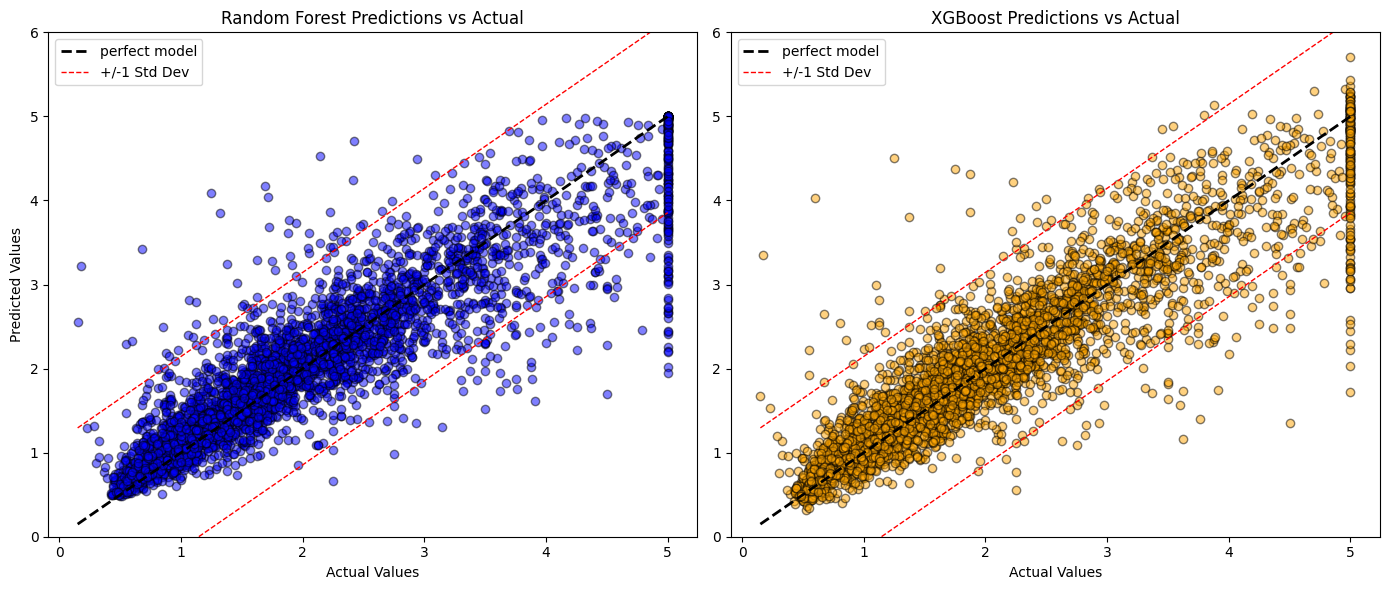

In [90]:
# 시각화
plt.figure(figsize=(14, 6))

# Random Forest plot
plt.subplot(1, 2, 1)
plt.scatter(y_test, y_pred_rf, alpha=0.5, color="blue",ec='k')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2,label="perfect model")
plt.plot([y_test.min(), y_test.max()], [y_test.min() + std_y, y_test.max() + std_y], 'r--', lw=1, label="+/-1 Std Dev")
plt.plot([y_test.min(), y_test.max()], [y_test.min() - std_y, y_test.max() - std_y], 'r--', lw=1, )
plt.ylim(0,6)
plt.title("Random Forest Predictions vs Actual")
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.legend()


# XGBoost plot
plt.subplot(1, 2, 2)
plt.scatter(y_test, y_pred_xgb, alpha=0.5, color="orange",ec='k')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2,label="perfect model")
plt.plot([y_test.min(), y_test.max()], [y_test.min() + std_y, y_test.max() + std_y], 'r--', lw=1, label="+/-1 Std Dev")
plt.plot([y_test.min(), y_test.max()], [y_test.min() - std_y, y_test.max() - std_y], 'r--', lw=1, )
plt.ylim(0,6)
plt.title("XGBoost Predictions vs Actual")
plt.xlabel("Actual Values")
plt.legend()
plt.tight_layout()
plt.show()

---

## `10` K-Means

- Types of **Clustering**
    1. **Partition-based**
        - divide data to non-overlapping groups
        - identify k clusters with minimal variance
        - e.g. k-means clustering
    2. **Density-based**
        - suitable for irregular clusters
        - e.g. DBSCAN
    3. **Hierarchical clustering**
        - generates dendrogram
        - relationships between clusters
        - method : Agglomerative / Divisive

- **`K-Means`**
    - partition-based
    - 클러스터들이 볼록하다고 가정
    - 클러스터 크기들이 균형적이라고 가정
    - 이상치와 노이즈에 민감함
    - 목표 : 각 데이터와 중심점 사이의 거리의 제곱의 합을 최소화
    
$$
\sum_{i=1}^{K} \sum_{x \in C_i} \lVert x - \mu_i \rVert^2
$$

- **Determining k**
    - Silhouette analysis : 응집력과 분리를 측정함
    - Elbow method
    - Davis-Bouldin Index

#### `10.1` Import libraries, load data and preprocess

In [93]:
!pip install numpy
!pip install pandas
!pip install matplotlib
!pip install scikit-learn
!pip install plotly

import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt 
from sklearn.cluster import KMeans 
from sklearn.datasets import make_blobs 
from sklearn.preprocessing import StandardScaler
import plotly.express as px

%matplotlib inline

import warnings
warnings.filterwarnings('ignore')

cust_df = pd.read_csv("https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML0101EN-SkillsNetwork/labs/Module%204/data/Cust_Segmentation.csv")
display(cust_df)

,Customer Id,Age,Edu,Years Employed,Income,Card Debt,Other Debt,Defaulted,Address,DebtIncomeRatio
0,1,41,2,6,19,0.124,1.073,0.0,NBA001,6.3
1,2,47,1,26,100,4.582,8.218,0.0,NBA021,12.8
2,3,33,2,10,57,6.111,5.802,1.0,NBA013,20.9
3,4,29,2,4,19,0.681,0.516,0.0,NBA009,6.3
4,5,47,1,31,253,9.308,8.908,0.0,NBA008,7.2
...,...,...,...,...,...,...,...,...,...,...
845,846,27,1,5,26,0.548,1.220,NaN,NBA007,6.8
846,847,28,2,7,34,0.359,2.021,0.0,NBA002,7.0
847,848,25,4,0,18,2.802,3.210,1.0,NBA001,33.4
848,849,32,1,12,28,0.116,0.696,0.0,NBA012,2.9


In [94]:
cust_df = cust_df.drop('Address', axis=1)

# NaN 드랍
cust_df = cust_df.dropna()
display(cust_df.info())

# 정규화
X = cust_df.values[:,1:] # leaves out `Customer ID`
Clus_dataSet = StandardScaler().fit_transform(X)

<class 'pandas.core.frame.DataFrame'>
Index: 700 entries, 0 to 849
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Customer Id      700 non-null    int64  
 1   Age              700 non-null    int64  
 2   Edu              700 non-null    int64  
 3   Years Employed   700 non-null    int64  
 4   Income           700 non-null    int64  
 5   Card Debt        700 non-null    float64
 6   Other Debt       700 non-null    float64
 7   Defaulted        700 non-null    float64
 8   DebtIncomeRatio  700 non-null    float64
dtypes: float64(4), int64(5)
memory usage: 54.7 KB


None

#### `10.2` Clustering

In [95]:
clusterNum = 3
k_means = KMeans(init = "k-means++", n_clusters = clusterNum, n_init = 12)
k_means.fit(X)
labels = k_means.labels_  # 클러스터 번호 추출

# 각 행에 클러스터 번호 할당
cust_df["Clus_km"] = labels

# 클러스터별 각 속성의 평균값 확인
display(cust_df.groupby('Clus_km').mean())

,Customer Id,Age,Edu,Years Employed,Income,Card Debt,Other Debt,Defaulted,DebtIncomeRatio
Clus_km,,,,,,,,,
0,439.80226,32.775895,1.632768,6.169492,30.642185,1.003795,2.090910,0.284369,10.146893
1,403.56129,41.103226,1.916129,15.135484,81.122581,3.024935,5.605258,0.180645,10.848387
2,374.00000,44.785714,3.000000,17.857143,219.714286,6.115429,11.546357,0.285714,8.064286


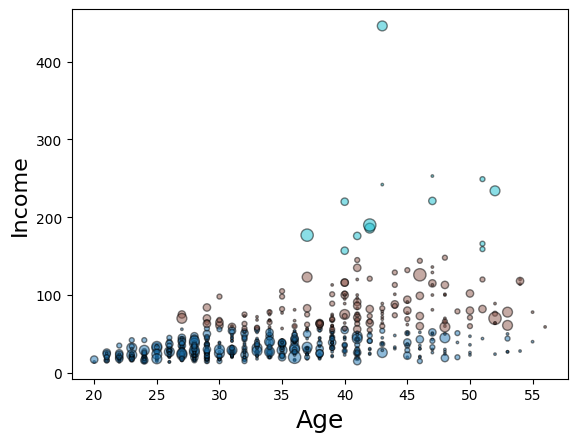

In [96]:
# distribution of customers based on their education, age and income
area = np.pi * ( X[:, 1])**2  
plt.scatter(X[:, 0], X[:, 3], s=area, c=labels.astype(float), cmap='tab10', ec='k',alpha=0.5)
plt.xlabel('Age', fontsize=18)
plt.ylabel('Income', fontsize=16)
plt.show()

In [97]:
# Create interactive 3D scatter plot
fig = px.scatter_3d(X, x=1, y=0, z=3, opacity=0.7, color=labels.astype(float))

fig.update_traces(marker=dict(size=5, line=dict(width=.25)), showlegend=False)
fig.update_layout(coloraxis_showscale=False, width=1000, height=800, scene=dict(
        xaxis=dict(title='Education'),
        yaxis=dict(title='Age'),
        zaxis=dict(title='Income')
    ))  # Remove color bar, resize plot

fig.show()

**결론**
<br>The 3 clusters can be:
<br>LATE CAREER, AFFLUENT, AND EDUCATED
<br>MID CAREER AND MIDDLE INCOME
<br>EARLY CAREER AND LOW INCOME

---

## `11` DBSCAN vs HDBSCAN

- **DBSCAN** : Density-based spatial clustering
    - 클러스터의 이웃을 정의할 때 특정한 밀도를 기준으로 함
    - 클러스터 내부의 점들과 노이즈를 구별해냄 (이상치에 강함)
    - 알고리즘
        1. 파라미터 (포인트 수 n과 각 이웃의 반경 epsilon) 선택
        2. 모든 데이터 포인트를 3 유형 중 하나로 라벨링 : core point / border point / noise point
- **HDBSCAN** : Hierarchical Density-based spatial clustering
    - 파라미터를 설정할 필요 없음
    - 알고리즘
        - 응집 기반 클러스터링 x 밀도 기반 클러스터링
        1. 각 점을 고유한 군집으로 식별함
        2. 밀도 임계값을 점진적으로 낮춤으로써 클러스터를 계층 구조로 통합함
        3. 압축 트리로 단순화됨

#### `11.1` Importing libraries and loading data

In [98]:
!pip install numpy==2.2.0
!pip install pandas==2.2.3
!pip install scikit-learn==1.6.0
!pip install matplotlib==3.9.3
!pip install hdbscan==0.8.40
!pip install geopandas==1.0.1
!pip install contextily==1.6.2
!pip install shapely==2.0.6

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
import hdbscan
from sklearn.preprocessing import StandardScaler

# geographical tools
import geopandas as gpd  # pandas dataframe-like geodataframes for geographical data
import contextily as ctx  # used for obtianing a basemap of Canada
from shapely.geometry import Point

import warnings
warnings.filterwarnings('ignore')

     ---------------------------------------- 0.0/6.9 MB ? eta -:--:--
     - -------------------------------------- 0.3/6.9 MB ? eta -:--:--
     - -------------------------------------- 0.3/6.9 MB ? eta -:--:--
     --- ------------------------------------ 0.5/6.9 MB 665.3 kB/s eta 0:00:10
     --- ------------------------------------ 0.5/6.9 MB 665.3 kB/s eta 0:00:10
     --- ------------------------------------ 0.5/6.9 MB 665.3 kB/s eta 0:00:10
     --- ------------------------------------ 0.5/6.9 MB 665.3 kB/s eta 0:00:10
     ---- ----------------------------------- 0.8/6.9 MB 413.7 kB/s eta 0:00:15
     ---- ----------------------------------- 0.8/6.9 MB 413.7 kB/s eta 0:00:15
     ---- ----------------------------------- 0.8/6.9 MB 413.7 kB/s eta 0:00:15
     ---- ----------------------------------- 0.8/6.9 MB 413.7 kB/s eta 0:00:15
     ------ --------------------------------- 1.0/6.9 MB 378.2 kB/s eta 0:00:16
     ------ --------------------------------- 1.0/6.9 MB 378.2 kB/s

  error: subprocess-exited-with-error
  
  × Building wheel for hdbscan (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> [39 lines of output]
      C:\Users\Public\Documents\ESTsoft\CreatorTemp\pip-build-env-gqptal6c\overlay\Lib\site-packages\setuptools\_distutils\dist.py:289: UserWarning: Unknown distribution option: 'test_suite'
        warnings.warn(msg)
      C:\Users\Public\Documents\ESTsoft\CreatorTemp\pip-build-env-gqptal6c\overlay\Lib\site-packages\setuptools\_distutils\dist.py:289: UserWarning: Unknown distribution option: 'tests_require'
        warnings.warn(msg)
      C:\Users\Public\Documents\ESTsoft\CreatorTemp\pip-build-env-gqptal6c\overlay\Lib\site-packages\setuptools\dist.py:759: SetuptoolsDeprecationWarning: License classifiers are deprecated.
      !!
      
              ********************************************************************************
              Please consider removing the following classifiers in favor of a SPDX license expressi

   ---------------------------------------- 0.0/19.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/19.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/19.2 MB ? eta -:--:--
    --------------------------------------- 0.3/19.2 MB ? eta -:--:--
    --------------------------------------- 0.3/19.2 MB ? eta -:--:--
    --------------------------------------- 0.3/19.2 MB ? eta -:--:--
   - -------------------------------------- 0.5/19.2 MB 382.9 kB/s eta 0:00:49
   - -------------------------------------- 0.5/19.2 MB 382.9 kB/s eta 0:00:49
   - -------------------------------------- 0.5/19.2 MB 382.9 kB/s eta 0:00:49
   - -------------------------------------- 0.8/19.2 MB 386.6 kB/s eta 0:00:48
   - -------------------------------------- 0.8/19.2 MB 386.6 kB/s eta 0:00:48
   - -------------------------------------- 0.8/19.2 MB 386.6 kB/s eta 0:00:48
   -- ------------------------------------- 1.0/19.2 MB 384.1 kB/s eta 0:00:48
   -- ---------------------

ModuleNotFoundError: No module named 'hdbscan'

In [ ]:
import requests
import zipfile
import io
import os

# URL of the ZIP file on the cloud server
zip_file_url = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/YcUk-ytgrPkmvZAh5bf7zA/Canada.zip'

# Directory to save the extracted TIFF file
output_dir = './'
os.makedirs(output_dir, exist_ok=True)

# Step 1: Download the ZIP file
response = requests.get(zip_file_url)
response.raise_for_status()  # Ensure the request was successful
# Step 2: Open the ZIP file in memory
with zipfile.ZipFile(io.BytesIO(response.content)) as zip_ref:
    # Step 3: Iterate over the files in the ZIP
    for file_name in zip_ref.namelist():
        if file_name.endswith('.tif'):  # Check if it's a TIFF file
            # Step 4: Extract the TIFF file
            zip_ref.extract(file_name, output_dir)
            print(f"Downloaded and extracted: {file_name}")

In [ ]:
# 클러스터 플롯 함수

def plot_clustered_locations(df,  title='Museums Clustered by Proximity'):
    """
    Plots clustered locations and overlays on a basemap.
    
    Parameters:
    - df: DataFrame containing 'Latitude', 'Longitude', and 'Cluster' columns
    - title: str, title of the plot
    """
    
    # Load the coordinates intto a GeoDataFrame
    gdf = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(df['Longitude'], df['Latitude']), crs="EPSG:4326")
    
    # Reproject to Web Mercator to align with basemap 
    gdf = gdf.to_crs(epsg=3857)
    
    # Create the plot
    fig, ax = plt.subplots(figsize=(15, 10))
    
    # Separate non-noise, or clustered points from noise, or unclustered points
    non_noise = gdf[gdf['Cluster'] != -1]
    noise = gdf[gdf['Cluster'] == -1]
    
    # Plot noise points 
    noise.plot(ax=ax, color='k', markersize=30, ec='r', alpha=1, label='Noise')
    
    # Plot clustered points, colured by 'Cluster' number
    non_noise.plot(ax=ax, column='Cluster', cmap='tab10', markersize=30, ec='k', legend=False, alpha=0.6)
    
    # Add basemap of  Canada
    ctx.add_basemap(ax, source='./Canada.tif', zoom=4)
    
    # Format plot
    plt.title(title, )
    plt.xlabel('Longitude', )
    plt.ylabel('Latitude', )
    ax.set_xticks([])
    ax.set_yticks([])
    plt.tight_layout()
    
    # Show the plot
    plt.show()

In [ ]:
url = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/r-maSj5Yegvw2sJraT15FA/ODCAF-v1-0.csv'
df = pd.read_csv(url, encoding = "ISO-8859-1")

df.head()

#### `11.2` EDA and preprocessing

In [ ]:
# facility types 변수 count
display(df.ODCAF_Facility_Type.value_counts())

# 특정 값으로 필터링
df = df[df.ODCAF_Facility_Type == 'museum']
print(df.ODCAF_Facility_Type.value_counts())

# 클러스터링 문제를 위해 위도와 경도 속성만 입력값으로 선택
df = df[['Latitude', 'Longitude']]
display(df.info())

# Latitude 값이 '..'이 아닌 행들을 다시 df에 저장
df = df[df.Latitude!='..']

# float으로 변환
df[['Latitude','Longitude']] = df[['Latitude','Longitude']].astype('float')

#### `11.3` Build a DBSCAN model

In [ ]:
# 전체 범위를 사용하지 않으므로 일반적 정규화 방법을 택하지 않음
# latitude has a range of +/- 90 degrees and longitude ranges from 0 to 360 degrees (2배)
coords_scaled = df.copy()
coords_scaled["Latitude"] = 2*coords_scaled["Latitude"]

In [ ]:
# 이웃이 생성되기 위한 최소 샘플 수
min_samples = 3

# 이웃이 되는 반경
eps = 1.0

# 거리 측정 방법
metric = 'euclidean'

dbscan = DBSCAN(eps=eps, min_samples=min_samples, metric=metric).fit(coords_scaled)

# 클러스터 번호 부여
df['Cluster'] = dbscan.fit_predict(coords_scaled)

# 각 클러스터의 크기 확인
df['Cluster'].value_counts()

In [ ]:
plot_clustered_locations(df, title='Museums Clusterd by Proximity')

#### `11.4` Build an HDBSCAN clustering model

In [ ]:
min_samples=None
min_cluster_size=3
hdb = hdbscan.HDBSCAN(min_samples=min_samples, min_cluster_size=min_cluster_size, metric='euclidean') 

# 클러스터 번호 부여
df['Cluster'] = hdb.fit_predict(coords_scaled)

# 각 클러스터의 크기 확인
df['Cluster'].value_counts()

In [ ]:
# Plot the museum clusters
plot_clustered_locations(df, title='Museums Hierarchically Clustered by Proximity')

---

## `12` Principal Component Analysis

- **Dimension Reduction** before clustering
    - PCA / t-SNE / UMAP
    - 고차원 클러스터를 핵심적인 2차원 또는 3차원으로 투영할 수 있음
    - 클러스터링 품질을 시각화하는 산점도 차트를 만들 수 있음

- **`PCA`** : Principle Componenet Analysis
    - 데이터가 선형적으로 상관되어 있다고 가정
    - 많은 분산을 유지하면서 주성분을 구성할 수 있음
    - Principle Componenets
        - 서로 직교함
        - feature 공간의 새 좌표계를 정의
        - 중요도 순서나 feature 공간의 설명하는 분산의 크기 순서로 구성됨

#### `12.1` Importing libraries, loading data and preprocessing

In [99]:
!pip install numpy==2.2.0
!pip install scikit-learn==1.6.0
!pip install matplotlib==3.9.3

import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn import datasets
from sklearn.preprocessing import StandardScaler

In [101]:
# Iris dataset
iris = datasets.load_iris()
X = iris.data
y = iris.target
target_names = iris.target_names

# 정규화
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(iris.target_names)

['setosa' 'versicolor' 'virginica']


#### `12.2` Initialize a PCA model

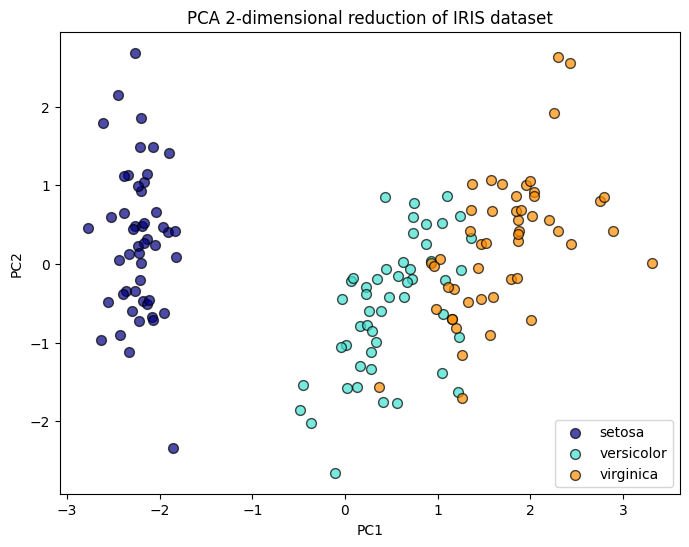

In [102]:
# PCA의 주성분 2개
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# plot : 2D data
plt.figure(figsize=(8,6))

colors = ['navy', 'turquoise', 'darkorange']
lw = 1

for color, i, target_name in zip(colors, [0, 1, 2], target_names):
    plt.scatter(X_pca[y == i, 0], X_pca[y == i, 1], color=color, s=50, ec='k',alpha=0.7, lw=lw,
                label=target_name)

plt.title('PCA 2-dimensional reduction of IRIS dataset',)
plt.xlabel("PC1",)
plt.ylabel("PC2",)
plt.legend(loc='best', shadow=False, scatterpoints=1,)
# plt.grid(True)
plt.show()

In [103]:
# 두 주성분이 feature space 분산의 몇 퍼센트를 설명하는지
100*pca.explained_variance_ratio_.sum()

np.float64(95.81320720000166)

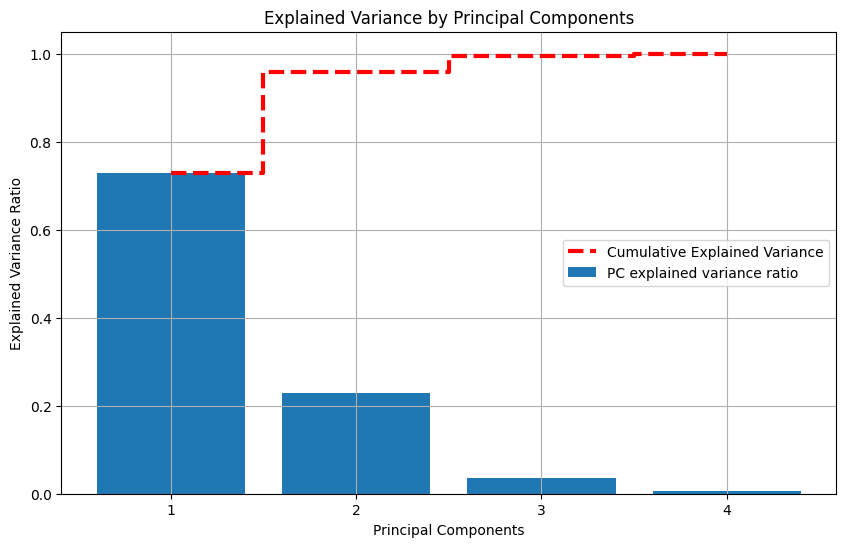

In [104]:
# 다시 PCA 적용
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# 전체 주성분별 설명 분산 비율
explained_variance_ratio = pca.explained_variance_ratio_

# 각 주성분이 설명하는 분산 비율 plot
plt.figure(figsize=(10,6))
plt.bar(x=range(1, len(explained_variance_ratio)+1), height=explained_variance_ratio, alpha=1, align='center', label='PC explained variance ratio' )
plt.ylabel('Explained Variance Ratio')
plt.xlabel('Principal Components')
plt.title('Explained Variance by Principal Components')

# 누적 설명 분산 비율 plot
cumulative_variance = np.cumsum(explained_variance_ratio)
plt.step(range(1, 5), cumulative_variance, where='mid', linestyle='--', lw=3,color='red', label='Cumulative Explained Variance')
# Only display integer ticks on the x-axis
plt.xticks(range(1, 5))
plt.legend()
plt.grid(True)
plt.show()

---

## `13` t-SNE & UMAP

- **`t-SNE`** : t-distributed stochastic neighbor embedding
    - 고차원 데이터 포인트를 저차원 공간에 매핑
    - 서로 가까운 점의 similarity을 보존하는 데 초점을 맞추고 먼 지점에서는 그렇지 않음
    - similarity(유사성) : 점 사이의 거리로 측정됨 
    - 하이퍼파라미터에 민감하여 튜닝하기 어려움
- **`UMAP`** : Uniform Manifold Approximation and Projection
    - t-SNE의 대안으로 자주 사용됨
    - Manifold theory : 데이터가 고차원 공간에 내장된 저차원 manifold에 있다고 가정함
    - 데이터의 고차원 그래프 표현을 구성함
    - 원본데이터의 점 간 관계를 가장 잘 보존하는 저차원 그래프 구조를 최적화함
    - scaling과 global structure 보존을 t-SNE보다 더 잘함 


#### `13.1` Importing libraries

In [106]:
!pip install numpy==2.2.0
!pip install pandas==2.2.3
!pip install matplotlib==3.9.3
!pip install plotly==5.24.1
!pip install umap-learn==0.5.7

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler

import umap.umap_ as UMAP 
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA

import plotly.express as px
from sklearn.datasets import make_blobs

   ---------------------------------------- 0.0/12.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/12.6 MB ? eta -:--:--
    --------------------------------------- 0.3/12.6 MB ? eta -:--:--
   - -------------------------------------- 0.5/12.6 MB 1.2 MB/s eta 0:00:11
   - -------------------------------------- 0.5/12.6 MB 1.2 MB/s eta 0:00:11
   - -------------------------------------- 0.5/12.6 MB 1.2 MB/s eta 0:00:11
   -- ------------------------------------- 0.8/12.6 MB 557.3 kB/s eta 0:00:22
   -- ------------------------------------- 0.8/12.6 MB 557.3 kB/s eta 0:00:22
   -- ------------------------------------- 0.8/12.6 MB 557.3 kB/s eta 0:00:22
   --- ------------------------------------ 1.0/12.6 MB 502.3 kB/s eta 0:00:23
   --- ------------------------------------ 1.0/12.6 MB 502.3 kB/s eta 0:00:23
   --- ------------------------------------ 1.0/12.6 MB 502.3 kB/s eta 0:00:23
   --- ------------------------------------ 1.0/12.6 MB 502.3 kB/s eta 0:00:23
   ---

ImportError: Numba needs NumPy 2.1 or less. Got NumPy 2.2.

#### `13.2` Generating data and standardizing

In [ ]:
# 클러스터 중심점 좌표 정의
centers = [[2, -6, -6],
           [-1, 9, 4]
           [-8, 7, 2],
           [4, 7, 9]]

# 클러스터 표준편차 정의
cluster_std = [1,1,2,3.5]

# blobs와 라벨 생성
X, labels_ = make_blobs(n_samples=500, centers=centers, n_features=3, cluster_std=cluster_std, random_state=42)

In [ ]:
# Plotly를 위한 df 생성
df = pd.DataFrame(X, columns=['X', 'Y', 'Z'])

# 3D 산점도 플롯 생성
fig = px.scatter_3d(df, x='X', y='Y', z='Z', color=labels_.astype(str) ,  opacity=0.7,  color_discrete_sequence=px.colors.qualitative.G10, title="3D Scatter Plot of Four Blobs")

fig.update_traces(marker=dict(size=5, line=dict(width=1, color='black')), showlegend=False)
fig.update_layout(coloraxis_showscale=False, width=1000, height=800)  # Remove color bar, resize plot

fig.show()

In [ ]:
# 3가지 투영 알고리즘 적용 전 데이터 표준화 단계
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

#### `13.3` apply t-SNE 

In [ ]:
# perplexity : 유효한 근접 이웃의 수, 이 파라미터 크기에 따라 결과가 많이 달라짐

tsne = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=1000)
X_tsne = tsne.fit_transform(X_scaled)

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111)
ax.scatter(X_tsne[:, 0], X_tsne[:, 1], c=labels_, cmap='viridis', s=50, alpha=0.7, edgecolor='k')
ax.set_title("2D t-SNE Projection of 3D Data")
ax.set_xlabel("t-SNE Component 1")
ax.set_ylabel("t-SNE Component 2")
ax.set_xticks([])
ax.set_yticks([])
plt.show()

#### `13.4` apply UMAP

In [ ]:
# Apply UMAP to reduce the dimensionality to 2D
umap_model = UMAP.UMAP(n_components=2, random_state=42, min_dist=0.5, spread=1,n_jobs=1)

X_umap = umap_model.fit_transform(X_scaled)

# Plot the 2D UMAP projection result 
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111)
ax.scatter(X_umap[:, 0], X_umap[:, 1], c=labels_, cmap='viridis', s=50, alpha=0.7, edgecolor='k')

ax.set_title("2D UMAP Projection of 3D Data")
ax.set_xlabel("UMAP Component 1", )
ax.set_ylabel("UMAP Component 2", )
ax.set_xticks([])
ax.set_yticks([])
plt.show()


#### `13.5` apply PCA

In [ ]:
# Apply PCA to reduce the dimensionality to 2D
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)


fig = plt.figure(figsize=(8, 6))

# Plot the 2D PCA result (right)
ax2 = fig.add_subplot(111)
scatter2 = ax2.scatter(X_pca[:, 0], X_pca[:, 1], c=labels_, cmap='viridis', s=50, alpha=0.7, edgecolor='k')
ax2.set_title("2D PCA Projection of 3-D Data")
ax2.set_xlabel("PCA 1")
ax2.set_ylabel("PCA 2")
ax2.set_xticks([])
ax2.set_yticks([])
plt.show()

---

## `14` Evaluation Techniques

#### `14.1` Evaluating classification metrics

- Accuracy

- **Confusion Matrix**
    - TP
    - TN
    - FP
    - FN

- **Precision** : TP / TP + FP <br>= (양성 예측 성공) / (양성 예측)

- **Recall** : TP / TP + FN <br>= (양성 예측 성공) / (실제 양성)

- **F1-score** : precision과 recall의 balanced mean(조화평균) <br>= (2 * Precision * Recall) / (precision + Recall)

#### `14.2` Evaluating regression metrics

- MAE
- MSE
- RMSE
- **R-squared** = 1 - Unexplained_Varience / Total_Variance
    - 가정 :  target variable이 input variables와 선형적으로 상관되어 있다고 가정. 비선형 모델에는 오해의 소지가 있음

#### `14.3` Evaluating Unsupervised Learning models

- Internal clustering evaluation metrics
    - Silhouette score
    - Davies-Bouldin Index
    - Inertia
- External clustering evaluation metrics
    - adjusted Rand Index
    - Nofrmalized Mutual Information
    - Fowlkes-Mallows Index
- Dimensionality reduction evaluation
    - Explained Variance Ratio in PCA
    - Reconstruction error
    - Neighborhood preservation

---

## `15` Regularization in Linear Regression

- regularization(정규화)
    - 계수의 크기를 줄임
    - 학습 중에 모델이 학습데이터에 **과적합**되는 것을 방지함

- **Reqularized Cost Function**(수정된 비용함수)을 사용하여 선형회귀 모델을 최적화함
    - = **MSE + λ * penalty**
        - λ : 패널티 항의 영향 조절
        - penalty 항은 Ridge, Lasso 등 method별로 다른 방식
        1. **Ridge** Regression은 **L2 penalty(계수의 제곱합)**를 추가하여 계수를 줄임 (when training, minimizing along with MSE)
        2. **Lasso** Regression은 **L1 penalty(계수의 절댓값 합)**를 추가하여 계수를 줄임 (when training, minimizing along with MSE)
            - 일반적으로 가장 좋은 성능
        - **이상치에 민감**한 선형회귀에 정규화 기법을 적용하면 이러한 오류를 줄임

#### `15.1` Importing libraries and generating data

In [108]:
!pip install numpy
!pip install pandas
!pip install scikit-learn
!pip install matplotlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import explained_variance_score, mean_absolute_error, mean_squared_error, r2_score

In [109]:
def regression_results(y_true, y_pred, regr_type):

    # Regression metrics
    ev = explained_variance_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred) 
    mse = mean_squared_error(y_true, y_pred) 
    r2 = r2_score(y_true, y_pred)
    
    print('Evaluation metrics for ' + regr_type + ' Linear Regression')
    print('explained_variance: ',  round(ev,4)) 
    print('r2: ', round(r2,4))
    print('MAE: ', round(mae,4))
    print('MSE: ', round(mse,4))
    print('RMSE: ', round(np.sqrt(mse),4))
    print()

In [110]:
# 합성 데이터 생성
noise=1
np.random.seed(42)
X = 2 * np.random.rand(1000, 1)
y = 4 + 3 * X + noise*np.random.randn(1000, 1)  # 선형 관계를 가짐 + 노이즈
y_ideal =  4 + 3 * X
# 특정 부분에 이상치를 추가하기 위한 부분 데이터셋
y_outlier = pd.Series(y.reshape(-1).copy())

# X가 임계치보다 큰 경우의 인덱스 구하기
threshold = 1.5  # Example threshold to add outliers for larger feature values
outlier_indices = np.where(X.flatten() > threshold)[0]

# 특정 부분에 이상치 추가
num_outliers = 5  # Number of outliers to add
selected_indices = np.random.choice(outlier_indices, num_outliers, replace=False)

# 특정 인덱스의 target value에 노이즈 추가
y_outlier[selected_indices] += np.random.uniform(50, 100, num_outliers)

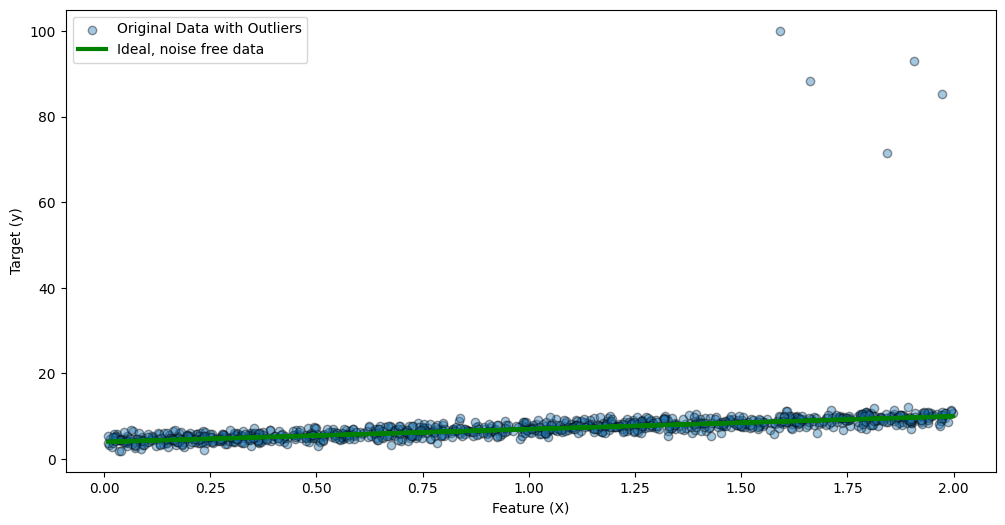

In [111]:
# 이상치가 추가된 데이터와 이상적 선 그래프 확인 plot
plt.figure(figsize=(12, 6))

# Scatter plot of the original data with outliers
plt.scatter(X, y_outlier, alpha=0.4,ec='k', label='Original Data with Outliers')
plt.plot(X, y_ideal,  linewidth=3, color='g',label='Ideal, noise free data')

plt.xlabel('Feature (X)')
plt.ylabel('Target (y)')
plt.title('')
plt.legend()
plt.show()

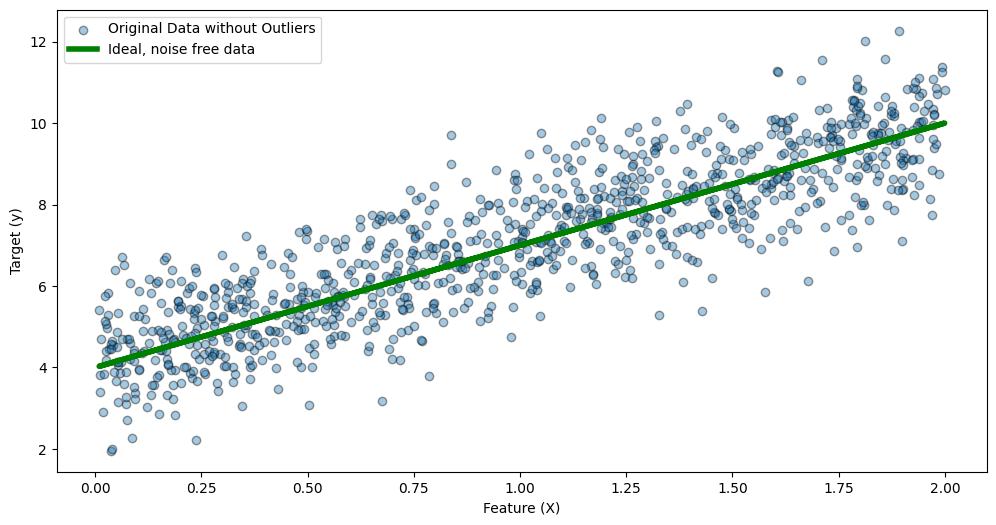

In [112]:
# 이상치가 제거된 데이터와 이상적 선 그래프 확인 plot
plt.figure(figsize=(12, 6))

# Scatter plot of the original data with outliers
plt.scatter(X, y, alpha=0.4,ec='k', label='Original Data without Outliers')
plt.plot(X, y_ideal,  linewidth=4, color='g',label='Ideal, noise free data')

plt.xlabel('Feature (X)')
plt.ylabel('Target (y)')
plt.title('')
plt.legend()
plt.show()

#### `15.2` Fit Ordinary, Ridge, and Lasso regression models

In [113]:
# Fit a simple linear regression model
lin_reg = LinearRegression()
lin_reg.fit(X, y_outlier)
y_outlier_pred_lin = lin_reg.predict(X)

# Fit a ridge regression model (regularization to control large coefficients)
ridge_reg = Ridge(alpha=1)
ridge_reg.fit(X, y_outlier)
y_outlier_pred_ridge = ridge_reg.predict(X)

# Fit a lasso regression model (regularization to control large coefficients)
lasso_reg = Lasso(alpha=.2)
lasso_reg.fit(X, y_outlier)
y_outlier_pred_lasso = lasso_reg.predict(X)

In [114]:
regression_results(y, y_outlier_pred_lin, 'Ordinary')
regression_results(y, y_outlier_pred_ridge, 'Ridge')
regression_results(y, y_outlier_pred_lasso, 'Lasso')

Evaluation metrics for Ordinary Linear Regression
explained_variance:  0.6748
r2:  0.6357
MAE:  0.9468
MSE:  1.4164
RMSE:  1.1901

Evaluation metrics for Ridge Linear Regression
explained_variance:  0.6766
r2:  0.6375
MAE:  0.9443
MSE:  1.4094
RMSE:  1.1872

Evaluation metrics for Lasso Linear Regression
explained_variance:  0.7394
r2:  0.7003
MAE:  0.8597
MSE:  1.1651
RMSE:  1.0794



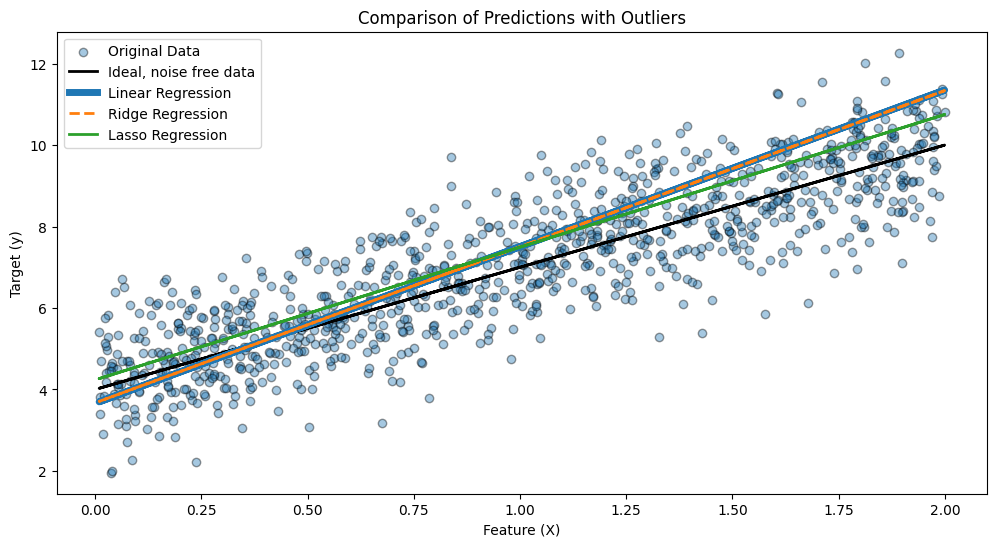

In [115]:
plt.figure(figsize=(12, 6))

# Scatter plot of the original data with outliers
plt.scatter(X, y, alpha=0.4,ec='k', label='Original Data')

# Plot the ideal regression line (noise free data)
plt.plot(X, y_ideal,  linewidth=2, color='k',label='Ideal, noise free data')

# Plot predictions from the simple linear regression model
plt.plot(X, y_outlier_pred_lin,  linewidth=5, label='Linear Regression')

# Plot predictions from the ridge regression model
plt.plot(X, y_outlier_pred_ridge, linestyle='--', linewidth=2, label='Ridge Regression')

# Plot predictions from the lasso regression model
plt.plot(X, y_outlier_pred_lasso,  linewidth=2, label='Lasso Regression')

plt.xlabel('Feature (X)')
plt.ylabel('Target (y)')
plt.title('Comparison of Predictions with Outliers')
plt.legend()
plt.show()

---

## `16` Machine Learning Pipelines and GridSearchCV

In [116]:
!pip install scikit-learn==1.6.0
!pip install matplotlib==3.9.3
!pip install seaborn==0.13.2

import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
import seaborn as sns
from sklearn.metrics import confusion_matrix

data = load_iris()
X, y = data.data, data.target
labels = data.target_names

# 파이프라인 설계
pipeline = Pipeline([
    ('scaler', StandardScaler()),       # Step 1: Standardize features
    ('pca', PCA(n_components=2),),       # Step 2: Reduce dimensions to 2 using PCA
    ('knn', KNeighborsClassifier(n_neighbors=5,))  # Step 3: K-Nearest Neighbors classifier
])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 학습데이터에 fitting
pipeline.fit(X_train, y_train)

# Measure the pipeline accuracy on the test data
test_score = pipeline.score(X_test, y_test)
print(f"{test_score:.3f}")

y_pred = pipeline.predict(X_test)

0.900


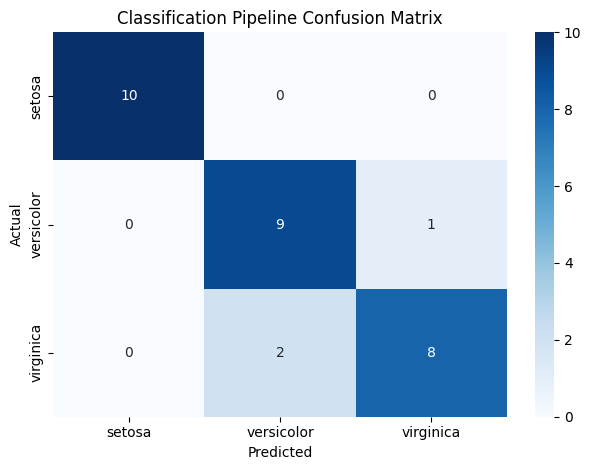

In [117]:
# generate the confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)

# Create a plot for the confusion matrix
plt.figure()
sns.heatmap(conf_matrix, annot=True, cmap='Blues', fmt='d',
            xticklabels=labels, yticklabels=labels)

# Set the title and labels
plt.title('Classification Pipeline Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

# Show the plot
plt.tight_layout()
plt.show()

In [118]:
# 파라미터를 정하지 않고 파이프라인 설계
pipeline = Pipeline(
                    [('scaler', StandardScaler()),
                     ('pca', PCA()),
                     ('knn', KNeighborsClassifier()) 
                    ]
                   )

# Hyperparameter search grid for numbers of PCA components and KNN neighbors
param_grid = {'pca__n_components': [2, 3],
              'knn__n_neighbors': [3, 5, 7]
             }

# cross validation method
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

best_model = GridSearchCV(estimator=pipeline,
                          param_grid=param_grid,
                          cv=cv,
                          scoring='accuracy',
                          verbose=2
                         )
best_model.fit(X_train, y_train)

Fitting 5 folds for each of 6 candidates, totalling 30 fits
[CV] END ............knn__n_neighbors=3, pca__n_components=2; total time=   0.0s
[CV] END ............knn__n_neighbors=3, pca__n_components=2; total time=   0.0s
[CV] END ............knn__n_neighbors=3, pca__n_components=2; total time=   0.0s
[CV] END ............knn__n_neighbors=3, pca__n_components=2; total time=   0.0s
[CV] END ............knn__n_neighbors=3, pca__n_components=2; total time=   0.0s
[CV] END ............knn__n_neighbors=3, pca__n_components=3; total time=   0.0s
[CV] END ............knn__n_neighbors=3, pca__n_components=3; total time=   0.0s
[CV] END ............knn__n_neighbors=3, pca__n_components=3; total time=   0.0s
[CV] END ............knn__n_neighbors=3, pca__n_components=3; total time=   0.0s
[CV] END ............knn__n_neighbors=3, pca__n_components=3; total time=   0.0s
[CV] END ............knn__n_neighbors=5, pca__n_components=2; total time=   0.0s
[CV] END ............knn__n_neighbors=5, pca__n_c

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('pca', PCA()),
                                       ('knn', KNeighborsClassifier())]),
             param_grid={'knn__n_neighbors': [3, 5, 7],
                         'pca__n_components': [2, 3]},
             scoring='accuracy', verbose=2)

In [119]:
test_score = best_model.score(X_test, y_test)
print(f"{test_score:.3f}")
print(best_model.best_params_)

0.933
{'knn__n_neighbors': 3, 'pca__n_components': 3}


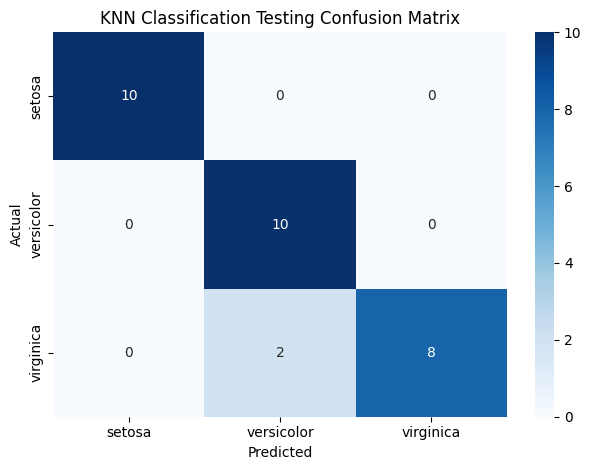

In [120]:
y_pred = best_model.predict(X_test)

# Generate the confusion matrix for KNN
conf_matrix = confusion_matrix(y_test, y_pred)

# Create a single plot for the confusion matrix
plt.figure()
sns.heatmap(conf_matrix, annot=True, cmap='Blues', fmt='d',
            xticklabels=labels, yticklabels=labels)

# Set the title and labels
plt.title('KNN Classification Testing Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

# Show the plot
plt.tight_layout()
plt.show()
